<a href="https://colab.research.google.com/github/sachin23-an/Latency_to_Execution/blob/main/Latency_to_Execution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Latency-to-Execution
### Can order-flow alpha survive the real market?
**Research → Signal → Latency → Queue → Execution → Adverse selection → P&L**

A short-horizon order-flow signal can predict the next price move and *still* lose money. By the time you observe the signal, decide, reach the exchange, get a queue position and get filled, the edge may be gone — or you only get filled when better-informed traders are about to move the price against you. This notebook measures that whole path, event by event, on a perpetual-futures order book.

> **Central question:** at what combination of signal latency, execution latency, queue position, fees and market regime does an order-flow strategy stop being economically viable?

| | Research question | Section |
|---|---|---|
| RQ1 | How quickly does order-flow information decay? | 5 |
| RQ2 | How much theoretical alpha survives increasing latency? | 6 |
| RQ3 | How much does the queue / fill assumption change realised profitability? | 9 |
| RQ4 | How much of passive market-making P&L is lost to adverse selection? | 8 |
| RQ5 | Does an order-flow-aware market maker beat a naive one after execution constraints? | 8–9 |
| RQ6 | Which latency / fee / regime combination makes the strategy viable? | 9–10 |

```
Market events → Order-book replay → OFI / micro-price / queue imbalance → walk-forward alpha
      → latency injection → execution engine → queue / fill model → market maker (A vs B)
      → fees → markouts / inventory / P&L → break-even latency & fee → hold-out check
```

**How to run.** Colab: *Runtime → Run all*. The first run downloads and parses the daily files (the slow part; they are cached afterwards — set `USE_DRIVE=True` in Section 1 to keep the cache on Google Drive). Everything after loading takes minutes. Figures go to `figures/`, tables to `results/`.

**Honesty rules baked into the code.** (1) Days are split into *warm-up / development / hold-out*; the hold-out is touched once, in Section 11. (2) Every model is fitted only on earlier days. (3) Every result carries a block-bootstrap confidence interval. (4) `DATA_MODE="synthetic"` exists only to test the machinery; every plot is stamped `[SYNTHETIC]`, and nothing measured on it is evidence about any real market. (5) Fees are *assumptions* — set them to your real tier.

## Definitions (read once — everything below uses these words)

| Term | Meaning |
|---|---|
| **Tick** | Smallest price increment. Here it is measured in **bps** (1 bp = 0.01 %) so instruments can be compared. |
| **Best bid / ask, touch** | Highest resting buy price / lowest resting sell price. The "touch" is that level; its size is the *touch depth* (in base units, e.g. BTC). |
| **Spread, mid** | `ask − bid`; `mid = (bid + ask)/2`. All returns below are mid-price returns in bps. |
| **Maker / taker** | A maker posts a resting order and waits; a taker crosses the spread and pays it. |
| **Post-only** | An order that is rejected instead of executing if it would cross the spread. |
| **Queue position** | Orders at one price fill first-come-first-served. Your order joins the back; "queue ahead" is the size that must trade or cancel before you fill. |
| **Queue imbalance (QI)** | `(bid depth − ask depth)/(bid depth + ask depth)` ∈ [−1, 1]. Positive = more resting buy interest. |
| **Micro-price** | Depth-weighted mid `(P_ask·Q_bid + P_bid·Q_ask)/(Q_bid+Q_ask)`; leans toward the thinner side, which is the side more likely to be consumed. Reported as `(micro − mid)` in bps. |
| **OFI (order-flow imbalance)** | Cont–Kukanov–Stoikov (2014): each book update contributes the *net change in buying vs selling pressure at the touch*, from price and size changes on both sides. Summed over a window and divided by average depth. |
| **TFI (trade-flow imbalance)** | Signed executed volume (buyer-initiated − seller-initiated) over a window, divided by average depth. |
| **Alpha** | Here: the walk-forward ridge prediction (bps) of the next-horizon mid-price move from the features above. |
| **IC** | Rank (Spearman) correlation between a prediction and the realised move. |
| **Latency (tick-to-trade)** | Time from *the information* to *your order reaching the matching engine*. Split into market-data staleness (`sig_lag`) + order-path delay (`exec_lat`). |
| **Adverse selection** | Your passive order fills *because* someone better informed is trading; the price then moves against you. |
| **Markout** | Price move after a fill, from our side: for a bought fill `mid(t+Δ) − fill price`, for a sold fill the reverse. Positive = the fill was good. |
| **Half-spread at fill** | What we "earned" by being filled at the touch vs the mid at that instant. |
| **Adverse-selection cost** | `half-spread at fill − markout(Δ)`: the part of the earned spread given back afterwards. |
| **Break-even fee** | The maker fee (bps of notional) at which net P&L is exactly zero. Positive: a fee can be paid. Negative: a rebate is needed just to break even. |
| **Walk-forward** | Fit on days before *d*, score day *d*, roll forward. No future data ever enters a fit. |
| **Block bootstrap** | Resample whole one-minute blocks (not single points) to get confidence intervals, because samples 100 ms apart are heavily autocorrelated. |

In [1]:
# ─────────────────────────────  1 · SETUP & CONFIG  ─────────────────────────────
import os, sys, math, time, zipfile, warnings, json, subprocess
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import requests
from IPython.display import display

try:
    import numba
except ImportError:                       # Colab normally ships numba; this is just a safety net
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "numba"], check=True)
    import numba
from numba import njit

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.width", 170); pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False})

# ══════════════════════════════ EXPERIMENT CONFIG ══════════════════════════════
CFG = dict(
    # ---- data -----------------------------------------------------------------
    SYMBOL="BTCUSDT",                 # Binance USD-M perpetual (research proxy – see README)
    DATA_MODE="binance",              # "binance" = real archive | "custom" = your own L1+trades files (e.g. NSE) | "synthetic" = dry-run ONLY
    CUSTOM_DIR="/content/custom_data",# only for DATA_MODE="custom": {SYMBOL}_{date}_quotes.csv and {SYMBOL}_{date}_trades.csv (schema in Section 2)
    DATES=["2024-02-05", "2024-02-06", "2024-02-07", "2024-02-08", "2024-02-09", "2024-02-12"],
    N_WARMUP=2,                       # first days: model warm-up only (never reported)
    N_HOLDOUT=2,                      # last days: untouched until Section 12
    SESSION_START_UTC="09:00",        # intraday window replayed each day
    SESSION_MINUTES=180,
    PREROLL_MS=60_000,                # first minute of each session only warms feature windows
    # ---- signal / analysis grid ------------------------------------------------
    GRID_MS=100,                      # decision / sampling grid
    HORIZONS_MS=[100, 250, 500, 1000, 2000, 5000, 10000],
    ALPHA_HORIZON_MS=1000,            # horizon the tradable alpha is trained on
    OFI_WINDOWS_MS=(500, 2000),
    LATENCIES_MS=[0, 1, 5, 10, 25, 50, 100, 250, 500],   # tick-to-trade latency grid
    TRADE_QUANTILE=0.90,              # taker analysis: act on the strongest 10 % of signals
    RIDGE_LAM=1e-2,
    # ---- market-maker simulator --------------------------------------------------
    BASE_LATENCY_MS=10,
    ORDER_QTY=0.01,                   # BTC per resting order
    INV_LIMIT=0.10,                   # BTC hard inventory limit (both strategies)
    REPEG_TICKS=2,                    # only re-peg a quote if the touch moved >= this many ticks
    PULL_QUANTILE=0.80,               # strategy B pulls the exposed side when |alpha| is in the top 20 %
    PULL_QUANTILES_SENS=[0.5, 0.7, 0.8, 0.9, 0.95],
    MARKOUT_MS=[1000, 5000, 10000],
    # ---- fees (ASSUMPTIONS – set to your real tier; bps of notional, negative = rebate) ----
    MAKER_FEE_BPS=0.0,
    TAKER_FEE_BPS=5.0,
    FEE_GRID_BPS=[-0.5, -0.2, -0.1, -0.05, 0.0, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0],
    # ---- statistics ----------------------------------------------------------------
    BOOT=2000, BLOCK_MS=60_000, SEED=7,
)
QUEUE_MODELS = {0: "conservative", 1: "proportional", 2: "optimistic"}
BASE_QUEUE_MODEL = 1

# derived --------------------------------------------------------------------------
DATES = CFG["DATES"]
assert len(DATES) > CFG["N_WARMUP"] + CFG["N_HOLDOUT"], "need at least one development day"
WARM_DAYS = list(range(0, CFG["N_WARMUP"]))
HOLD_DAYS = list(range(len(DATES) - CFG["N_HOLDOUT"], len(DATES)))
DEV_DAYS = [i for i in range(len(DATES)) if i not in WARM_DAYS and i not in HOLD_DAYS]
SYNTH = CFG["DATA_MODE"] == "synthetic"
TAG = "  [SYNTHETIC DATA – pipeline check, not evidence]" if SYNTH else ""
RNG = np.random.default_rng(CFG["SEED"])

IN_COLAB = "google.colab" in sys.modules
USE_DRIVE = False        # True → keep downloads/results on Google Drive so they survive a runtime reset
if IN_COLAB and USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    WORK = "/content/drive/MyDrive/latency_to_execution"
else:
    WORK = "/content/latency_to_execution" if IN_COLAB else os.path.abspath("./latency_to_execution_work")
DATA_DIR, FIG_DIR, RES_DIR = (os.path.join(WORK, d) for d in ("data", "figures", "results"))
for d in (DATA_DIR, FIG_DIR, RES_DIR):
    os.makedirs(d, exist_ok=True)

def savefig(name, fig=None):
    (fig or plt.gcf()).savefig(os.path.join(FIG_DIR, name + ".png"), dpi=150, bbox_inches="tight")

print(f"mode={CFG['DATA_MODE']}  symbol={CFG['SYMBOL']}  numba={numba.__version__}  work_dir={WORK}")
print(f"days: warm-up={WARM_DAYS}  development={DEV_DAYS}  hold-out={HOLD_DAYS}")

mode=binance  symbol=BTCUSDT  numba=0.61.2  work_dir=/content/latency_to_execution
days: warm-up=[0, 1]  development=[2, 3]  hold-out=[4, 5]


### What Section 1 did
Defined every experiment knob in one dictionary (`CFG`) and split the days into **warm-up** (only used to fit the first model), **development** (where all analysis and design choices are made) and **hold-out** (untouched until Section 11).

**Things you will want to change:** `DATES`, `SESSION_START_UTC` / `SESSION_MINUTES`, the fee assumptions, and `ORDER_QTY` / `INV_LIMIT`. Two definitions matter for reading results later: `LATENCIES_MS` is the *total* tick-to-trade latency (data staleness + order path), and `PULL_QUANTILE` (the threshold for strategy B) is fixed **before** results are seen; Section 9 shows how sensitive the outcome is to it.

In [2]:
# ─────────────────────────────  2 · DATA LAYER  ─────────────────────────────
BASE_URL = "https://data.binance.vision/data/futures/um/daily"
BT_COLS = ["update_id", "best_bid_price", "best_bid_qty", "best_ask_price", "best_ask_qty",
           "transaction_time", "event_time"]
AT_COLS = ["agg_trade_id", "price", "quantity", "first_trade_id", "last_trade_id",
           "transact_time", "is_buyer_maker"]

@dataclass
class Day:
    date: str
    t0: int; t1: int; tick: float
    q_t: np.ndarray; bid_px: np.ndarray; bid_qty: np.ndarray; ask_px: np.ndarray; ask_qty: np.ndarray
    tr_t: np.ndarray; tr_px: np.ndarray; tr_qty: np.ndarray; tr_side: np.ndarray   # side: +1 aggressor BUY, -1 aggressor SELL
    diag: dict = field(default_factory=dict)
    synthetic: bool = False

def session_bounds_ms(date):
    t0 = int(pd.Timestamp(f"{date} {CFG['SESSION_START_UTC']}", tz="UTC").timestamp() * 1000)
    return t0, t0 + CFG["SESSION_MINUTES"] * 60_000

# ---------------------------------------------------------------- download -----------
def download(kind, symbol, date):
    fn = f"{symbol}-{kind}-{date}.zip"
    path = os.path.join(DATA_DIR, fn)
    if os.path.exists(path) and os.path.getsize(path) > 0:
        return path
    url = f"{BASE_URL}/{kind}/{symbol}/{fn}"
    t = time.time()
    r = requests.get(url, stream=True, timeout=120)
    if r.status_code == 404:
        raise FileNotFoundError(f"404 for {url}\nThe archive does not publish this file. Pick dates inside the published range "
                                f"(bookTicker for BTCUSDT futures has, at times, stopped in early 2024) – see README §Data.")
    r.raise_for_status()
    with open(path + ".part", "wb") as f:
        for chunk in r.iter_content(1 << 20):
            f.write(chunk)
    os.replace(path + ".part", path)
    print(f"  downloaded {fn}  {os.path.getsize(path)/1e6:,.0f} MB  in {time.time()-t:,.0f}s")
    return path

# ---------------------------------------------------------------- parsing -----------
def _to_ms(x):
    x = np.asarray(x, dtype=np.int64)
    return x // 1000 if x.size and np.median(x) > 1e14 else x        # tolerate µs timestamps

def _read_zip_window(path, names, dtypes, tcol, t0, t1, chunksize=3_000_000):
    """Stream a zipped CSV, keeping only rows whose timestamp lies in [t0, t1). Handles header/no-header files."""
    zf = zipfile.ZipFile(path); member = zf.namelist()[0]
    with zf.open(member) as f:
        first = f.readline().decode("utf-8", "ignore").strip()
    header = 0 if first[:1].isalpha() else None
    use = names[: len(first.split(","))]
    parts, n_raw = [], 0
    with zf.open(member) as f:
        for ch in pd.read_csv(f, header=header, names=use, dtype={k: v for k, v in dtypes.items() if k in use},
                              chunksize=chunksize):
            n_raw += len(ch)
            tt = _to_ms(ch[tcol].to_numpy())
            if tt.min() > t1 + 600_000:          # files are (nearly) time-ordered: stop once we are >10 min past the window
                break
            m = (tt >= t0) & (tt < t1)
            if m.any():
                sub = ch.loc[m].copy(); sub[tcol] = tt[m]
                parts.append(sub)
    if not parts:
        raise ValueError(f"{os.path.basename(path)}: no rows inside the requested window ({n_raw:,} rows scanned)")
    return pd.concat(parts, ignore_index=True), n_raw

def parse_book_ticker(path, t0, t1):
    dt = {"update_id": "int64", "best_bid_price": "float64", "best_bid_qty": "float64",
          "best_ask_price": "float64", "best_ask_qty": "float64", "transaction_time": "int64", "event_time": "int64"}
    df, n_raw = _read_zip_window(path, BT_COLS, dt, "transaction_time", t0, t1)
    raw_inv = float((np.diff(df["transaction_time"].to_numpy()) < 0).mean())        # file order vs time order
    df = df.sort_values(["transaction_time", "update_id"], kind="mergesort").reset_index(drop=True)
    uid_inv = float((np.diff(df["update_id"].to_numpy()) < 0).mean())               # update-id order after time sort
    q = pd.DataFrame({"t": df["transaction_time"].to_numpy(), "bid_px": df["best_bid_price"].to_numpy(),
                      "bid_qty": df["best_bid_qty"].to_numpy(), "ask_px": df["best_ask_price"].to_numpy(),
                      "ask_qty": df["best_ask_qty"].to_numpy()})
    return q, dict(rows_scanned=n_raw, raw_time_inversions=raw_inv, updateid_inversions_after_sort=uid_inv)

def parse_agg_trades(path, t0, t1):
    dt = {"agg_trade_id": "int64", "price": "float64", "quantity": "float64", "first_trade_id": "int64",
          "last_trade_id": "int64", "transact_time": "int64", "is_buyer_maker": "str"}
    df, n_raw = _read_zip_window(path, AT_COLS, dt, "transact_time", t0, t1)
    df = df.sort_values(["transact_time", "agg_trade_id"], kind="mergesort")
    maker_buy = df["is_buyer_maker"].astype(str).str.lower().eq("true").to_numpy()
    tr = pd.DataFrame({"t": df["transact_time"].to_numpy(), "px": df["price"].to_numpy(),
                       "qty": df["quantity"].to_numpy(), "side": np.where(maker_buy, -1, 1).astype(np.int8)})
    return tr, dict(trade_rows_scanned=n_raw)

def finalize_day(date, t0, t1, q, tr, diag, synthetic=False):
    n0 = len(q)
    ok = (np.isfinite(q[["bid_px", "bid_qty", "ask_px", "ask_qty"]].to_numpy()).all(1) & (q.bid_qty.to_numpy() > 0)
          & (q.ask_qty.to_numpy() > 0) & (q.bid_px.to_numpy() > 0) & (q.bid_px.to_numpy() < q.ask_px.to_numpy()))
    q = q.loc[ok].reset_index(drop=True)
    vals = q[["bid_px", "bid_qty", "ask_px", "ask_qty"]].to_numpy()
    keep = np.r_[True, (vals[1:] != vals[:-1]).any(1)]                 # drop consecutive identical states
    q = q.loc[keep].reset_index(drop=True)
    tr = tr.loc[tr.qty > 0].reset_index(drop=True)
    d_bid = np.abs(np.diff(q.bid_px.to_numpy())); d_bid = np.round(d_bid[d_bid > 0], 8)
    tick = float(d_bid.min()) if d_bid.size else 0.1
    diag = dict(diag, quotes_raw=n0, quotes_dropped_invalid=int((~ok).sum()), quotes_dropped_dupes=int((~keep).sum()),
                n_quotes=len(q), n_trades=len(tr))
    return Day(date, t0, t1, tick, q.t.to_numpy().astype(np.int64), q.bid_px.to_numpy(float), q.bid_qty.to_numpy(float),
               q.ask_px.to_numpy(float), q.ask_qty.to_numpy(float), tr.t.to_numpy().astype(np.int64),
               tr.px.to_numpy(float), tr.qty.to_numpy(float), tr.side.to_numpy(np.int8), diag, synthetic)

# ---------------------------------------------------------------- synthetic data (dry-run only) --------
@njit
def _synth_core(n_events, seed, t0_ms, p0, tick, rate_hz):
    """Tiny queue-reactive toy market: a latent 'pressure' z (OU) tilts market-order side, adds and cancels.
    It exists ONLY to exercise the pipeline end-to-end. Nothing measured on it is evidence about real markets."""
    np.random.seed(seed)
    mq = 2 * n_events + 4
    q_t = np.empty(mq, np.int64); q_bp = np.empty(mq); q_bq = np.empty(mq); q_ap = np.empty(mq); q_aq = np.empty(mq)
    tr_t = np.empty(n_events + 2, np.int64); tr_p = np.empty(n_events + 2); tr_q = np.empty(n_events + 2)
    tr_s = np.empty(n_events + 2, np.int8)
    nq = 0; ntr = 0
    bid = int(round(p0 / tick)); ask = bid + 1
    bq = 1.2; aq = 1.2; z = 0.0; t = float(t0_ms)
    kappa = 0.3; sig = 0.7
    for e in range(n_events):
        dt = -np.log(1.0 - np.random.random()) / rate_hz
        t += dt * 1000.0
        z += -kappa * z * dt + sig * np.sqrt(dt) * np.random.normal()
        th = np.tanh(z)
        p_buy = 1.0 / (1.0 + np.exp(-1.5 * z))
        r_ab = 1.0 * (1.0 + 0.6 * th); r_aa = 1.0 * (1.0 - 0.6 * th)
        r_cb = 0.45 * bq * (1.0 - 0.5 * th); r_ca = 0.45 * aq * (1.0 + 0.5 * th)
        r_mb = 0.8 * p_buy; r_ms = 0.8 * (1.0 - p_buy)
        tot = r_ab + r_aa + r_cb + r_ca + r_mb + r_ms
        u = np.random.random() * tot
        ti = int(t); dep = 0
        if u < r_ab:
            bq += np.random.exponential(0.30)
        elif u < r_ab + r_aa:
            aq += np.random.exponential(0.30)
        elif u < r_ab + r_aa + r_cb:
            c = min(bq, np.random.exponential(0.40)); bq -= c
            if bq < 1e-6: dep = 1
        elif u < r_ab + r_aa + r_cb + r_ca:
            c = min(aq, np.random.exponential(0.40)); aq -= c
            if aq < 1e-6: dep = 2
        elif u < r_ab + r_aa + r_cb + r_ca + r_mb:
            f = min(np.random.exponential(0.30) + 0.01, aq)
            tr_t[ntr] = ti; tr_p[ntr] = round(ask * tick, 1); tr_q[ntr] = f; tr_s[ntr] = 1; ntr += 1
            aq -= f
            if aq < 1e-6: dep = 2
        else:
            f = min(np.random.exponential(0.30) + 0.01, bq)
            tr_t[ntr] = ti; tr_p[ntr] = round(bid * tick, 1); tr_q[ntr] = f; tr_s[ntr] = -1; ntr += 1
            bq -= f
            if bq < 1e-6: dep = 1
        if dep == 1:
            bid -= 1; bq = np.random.exponential(0.8) + 0.05
        elif dep == 2:
            ask += 1; aq = np.random.exponential(0.8) + 0.05
        if ask - bid > 1 and np.random.random() < 0.9:
            if np.random.random() < 0.5 + 0.3 * th:
                bid += 1; bq = np.random.exponential(0.5) + 0.05
            else:
                ask -= 1; aq = np.random.exponential(0.5) + 0.05
        q_t[nq] = ti; q_bp[nq] = round(bid * tick, 1); q_bq[nq] = bq; q_ap[nq] = round(ask * tick, 1); q_aq[nq] = aq; nq += 1
    return q_t[:nq], q_bp[:nq], q_bq[:nq], q_ap[:nq], q_aq[:nq], tr_t[:ntr], tr_p[:ntr], tr_q[:ntr], tr_s[:ntr]

def make_synthetic_day(date, i, rate_hz=120.0):
    t0, t1 = session_bounds_ms(date)
    n = int((t1 - t0) / 1000 * rate_hz)
    qt, bp, bq, ap, aq, tt, tp, tq, ts = _synth_core(n, 1000 + i, t0, 40000.0 + 25 * i, 0.1, rate_hz)
    q = pd.DataFrame(dict(t=qt, bid_px=bp, bid_qty=bq, ask_px=ap, ask_qty=aq))
    tr = pd.DataFrame(dict(t=tt, px=tp, qty=tq, side=ts))
    return finalize_day(date, t0, t1, q, tr, dict(source="synthetic"), synthetic=True)

# ---------------------------------------------------------------- bring-your-own data (e.g. NSE Nifty futures) ------
def load_day_custom(date):
    """Schema (UTC epoch-millisecond timestamps, one file pair per day):
       {CUSTOM_DIR}/{SYMBOL}_{date}_quotes.csv : t_ms,bid_px,bid_qty,ask_px,ask_qty        (top-of-book updates)
       {CUSTOM_DIR}/{SYMBOL}_{date}_trades.csv : t_ms,px,qty,side                            (side = +1 buyer-initiated, -1 seller-initiated)
       NSE full-depth history is not public; it comes from NSE Data & Analytics / authorised vendors, or from your own recording of a broker feed.
       Set SESSION_START_UTC to the cash/derivatives open (NSE 09:15 IST = 03:45 UTC), ORDER_QTY/INV_LIMIT in contracts, and fees to NSE costs."""
    t0, t1 = session_bounds_ms(date)
    base = os.path.join(CFG["CUSTOM_DIR"], f"{CFG['SYMBOL']}_{date}")
    q = pd.read_csv(base + "_quotes.csv").rename(columns={"t_ms": "t"}); tr = pd.read_csv(base + "_trades.csv").rename(columns={"t_ms": "t"})
    q = q[(q.t >= t0) & (q.t < t1)].sort_values("t", kind="mergesort").reset_index(drop=True)
    tr = tr[(tr.t >= t0) & (tr.t < t1)].sort_values("t", kind="mergesort").reset_index(drop=True); tr["side"] = tr["side"].astype(np.int8)
    return finalize_day(date, t0, t1, q[["t", "bid_px", "bid_qty", "ask_px", "ask_qty"]], tr[["t", "px", "qty", "side"]], dict(source="custom"))

# ---------------------------------------------------------------- unified loader ---------------------
def load_day(date, i):
    if CFG["DATA_MODE"] == "synthetic":
        return make_synthetic_day(date, i)
    if CFG["DATA_MODE"] == "custom":
        return load_day_custom(date)
    t0, t1 = session_bounds_ms(date)
    cache = os.path.join(DATA_DIR, f"{CFG['SYMBOL']}_{date}_{CFG['SESSION_START_UTC'].replace(':','')}_{CFG['SESSION_MINUTES']}.npz")
    if os.path.exists(cache):
        z = np.load(cache, allow_pickle=True)
        return Day(date, t0, t1, float(z["tick"]), z["q_t"], z["bid_px"], z["bid_qty"], z["ask_px"], z["ask_qty"],
                   z["tr_t"], z["tr_px"], z["tr_qty"], z["tr_side"], json.loads(str(z["diag"])))
    p_bt = download("bookTicker", CFG["SYMBOL"], date)
    p_at = download("aggTrades", CFG["SYMBOL"], date)
    q, d1 = parse_book_ticker(p_bt, t0, t1)
    tr, d2 = parse_agg_trades(p_at, t0, t1)
    day = finalize_day(date, t0, t1, q, tr, {**d1, **d2})
    np.savez_compressed(cache, tick=day.tick, q_t=day.q_t, bid_px=day.bid_px, bid_qty=day.bid_qty, ask_px=day.ask_px,
                        ask_qty=day.ask_qty, tr_t=day.tr_t, tr_px=day.tr_px, tr_qty=day.tr_qty, tr_side=day.tr_side,
                        diag=json.dumps(day.diag))
    return day

### What Section 2 did — and what the data can and cannot support
* **Source:** Binance's public archive of USD-M futures — `bookTicker` (best bid/ask price and size at every change) and `aggTrades` (executed trades with the aggressor side). This is **level-1** data: only the touch is visible, not deeper levels. So the headline OFI here is *top-of-book* OFI. `ofi_multilevel()` already accepts `(n, L)` arrays, so if you record your own depth stream the same code gives multi-level OFI.
* **Known data problem handled:** the `bookTicker` files have been reported to contain rows out of time order; the loader re-sorts by `(transaction_time, update_id)` and reports how many inversions it found. Check the quality table in Section 3.
* **Availability:** third-party tooling notes the futures `bookTicker` archive for BTCUSDT was published only up to about March 2024 (as observed in April 2026). If a download returns 404, choose dates inside the published range — the loader tells you.
* **Not verified by the author:** the download/parse path was tested on files built to the documented column layout, *not* on the live Binance servers. If a column name differs, `BT_COLS` / `AT_COLS` at the top of the cell are the only things to edit.
* **NSE / Nifty:** full-depth NSE history is not free — it is sold by NSE Data & Analytics and authorised vendors. `DATA_MODE="custom"` accepts your own top-of-book + trades CSVs (schema in the docstring of `load_day_custom`), so the identical study can be re-run on Nifty futures if you obtain or record such data.
* **Synthetic mode:** a toy queue-reactive market used to prove the pipeline runs end to end. It is strongly predictable by construction.

[1/6] 2024-02-05 …   downloaded BTCUSDT-bookTicker-2024-02-05.zip  267 MB  in 12s
  downloaded BTCUSDT-aggTrades-2024-02-05.zip  12 MB  in 2s
3,130,084 quote updates, 85,361 trades
[2/6] 2024-02-06 …   downloaded BTCUSDT-bookTicker-2024-02-06.zip  242 MB  in 11s
  downloaded BTCUSDT-aggTrades-2024-02-06.zip  9 MB  in 1s
4,051,048 quote updates, 110,771 trades
[3/6] 2024-02-07 …   downloaded BTCUSDT-bookTicker-2024-02-07.zip  250 MB  in 10s
  downloaded BTCUSDT-aggTrades-2024-02-07.zip  11 MB  in 2s
3,119,622 quote updates, 83,738 trades
[4/6] 2024-02-08 …   downloaded BTCUSDT-bookTicker-2024-02-08.zip  293 MB  in 13s
  downloaded BTCUSDT-aggTrades-2024-02-08.zip  14 MB  in 1s
3,566,877 quote updates, 110,992 trades
[5/6] 2024-02-09 …   downloaded BTCUSDT-bookTicker-2024-02-09.zip  377 MB  in 16s
  downloaded BTCUSDT-aggTrades-2024-02-09.zip  24 MB  in 2s
5,547,638 quote updates, 241,931 trades
[6/6] 2024-02-12 …   downloaded BTCUSDT-bookTicker-2024-02-12.zip  401 MB  in 17s
  downloade

day,0,1,2,3,4,5
date,2024-02-05,2024-02-06,2024-02-07,2024-02-08,2024-02-09,2024-02-12
quotes,3130084,4051048,3119622,3566877,5547638,4929045
trades,85361,110771,83738,110992,241931,130561
quotes_per_s,289.8226,375.0970,288.8539,330.2664,513.6702,456.3931
trades_per_s,7.9038,10.2566,7.7535,10.2770,22.4010,12.0890
tick,0.1000,0.1000,0.1000,0.0200,0.1000,0.1000
tick_bps,0.0232,0.0233,0.0233,0.0045,0.0214,0.0209
pct_spread_1tick,99.1927,98.9093,99.1984,0.0000,98.1945,99.1667
spread_bps_med,0.0232,0.0233,0.0233,0.0224,0.0214,0.0209
med_touch_qty,5.5005,5.6900,5.9520,5.9695,4.7075,4.5255


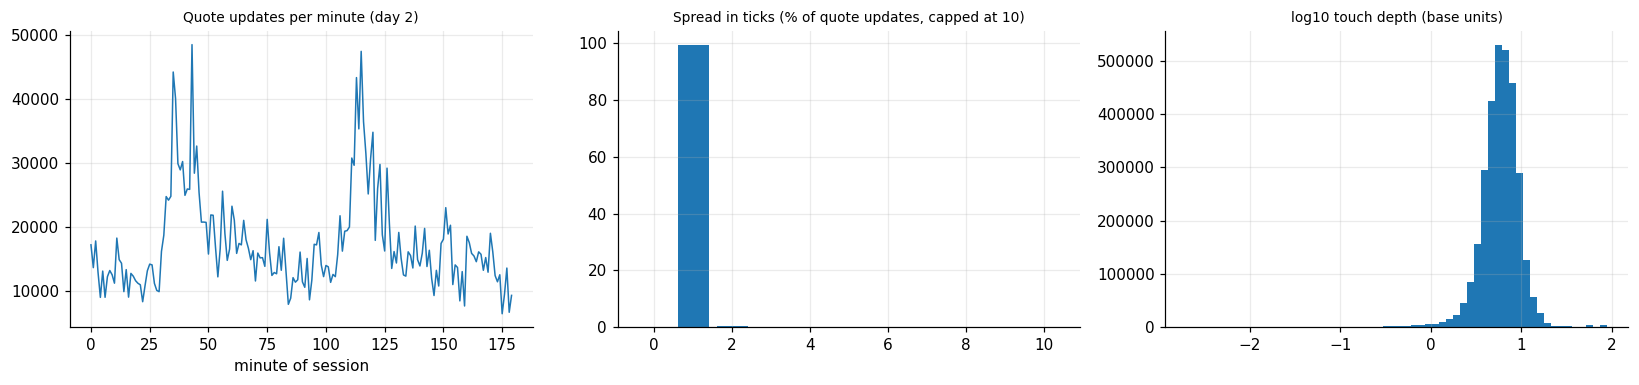

In [3]:
# ─────────────────────────────  3 · LOAD + DATA-QUALITY REPORT  ─────────────────────────────
t_start = time.time()
DAYS = []
for i, d in enumerate(DATES):
    print(f"[{i+1}/{len(DATES)}] {d} …", end=" ")
    DAYS.append(load_day(d, i))
    print(f"{len(DAYS[-1].q_t):,} quote updates, {len(DAYS[-1].tr_t):,} trades")
print(f"loaded in {time.time()-t_start:,.0f}s")

def quality_report(days):
    rows = []
    for i, d in enumerate(days):
        sec = (d.t1 - d.t0) / 1000
        spread_ticks = np.rint((d.ask_px - d.bid_px) / d.tick)
        mid = 0.5 * (d.bid_px + d.ask_px)
        gaps = np.diff(d.q_t) / 1000
        rows.append(dict(day=i, date=d.date, quotes=len(d.q_t), trades=len(d.tr_t), quotes_per_s=len(d.q_t) / sec,
                         trades_per_s=len(d.tr_t) / sec, tick=d.tick, tick_bps=d.tick / mid.mean() * 1e4,
                         pct_spread_1tick=100 * np.mean(spread_ticks == 1), spread_bps_med=np.median((d.ask_px - d.bid_px) / mid * 1e4),
                         med_touch_qty=np.median(0.5 * (d.bid_qty + d.ask_qty)), max_gap_s=gaps.max(),
                         dropped_invalid=d.diag.get("quotes_dropped_invalid", 0), dupes=d.diag.get("quotes_dropped_dupes", 0),
                         file_time_inversions=d.diag.get("raw_time_inversions", np.nan),
                         updid_inversions=d.diag.get("updateid_inversions_after_sort", np.nan),
                         roles="warm-up" if i in WARM_DAYS else ("hold-out" if i in HOLD_DAYS else "dev")))
    return pd.DataFrame(rows).set_index("day")

QR = quality_report(DAYS)
display(QR.T)

fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
d0 = DAYS[DEV_DAYS[0]]
per_min = np.bincount(((d0.q_t - d0.t0) // 60_000).astype(int))
ax[0].plot(per_min, lw=1); ax[0].set_title(f"Quote updates per minute (day {DEV_DAYS[0]}){TAG}", fontsize=9); ax[0].set_xlabel("minute of session")
st = np.rint((d0.ask_px - d0.bid_px) / d0.tick).astype(int); vc = pd.Series(np.minimum(st, 10)).value_counts(normalize=True).sort_index()
ax[1].bar(vc.index, 100 * vc.values); ax[1].set_title("Spread in ticks (% of quote updates, capped at 10)", fontsize=9)
ax[2].hist(np.log10(0.5 * (d0.bid_qty + d0.ask_qty)), bins=60); ax[2].set_title("log10 touch depth (base units)", fontsize=9)
plt.tight_layout(); savefig("01_data_quality"); plt.show()

# hard stops: things that would silently poison every later result
assert QR["quotes"].min() > 10_000, "suspiciously few quote updates – check the session window / files"
if not SYNTH:
    if QR["file_time_inversions"].max() > 0.001:
        print("NOTE: raw file order is not time order in some files – the loader re-sorted by (transaction_time, update_id).")
    if QR["updid_inversions"].max() > 0.001:
        print("WARNING: update_id is not monotone after the time sort → replay order may be imperfect; treat sub-ms results with care.")

### How to read the data-quality table
* **`pct_spread_1tick`** — if this is ~100 %, the book is "tick-constrained": you cannot quote *inside* the spread, so a market maker can only join the touch. That is the situation on BTC perpetuals and it shapes the whole study.
* **`tick_bps`** — the tick in bps. Compare with any fee you assume: a fee larger than a tick means a touch-quoting market maker needs positive markouts just to break even.
* **`file_time_inversions` / `updid_inversions`** — non-zero means the raw file order was not time order (handled by sorting) or that `update_id` disagrees with time after sorting (then sub-millisecond ordering is uncertain).
* **`max_gap_s`** — long gaps indicate missing data; investigate before trusting that day.

In [4]:
# ─────────────────────────────  4 · ORDER-BOOK SIGNALS  +  LOOK-AHEAD AUDIT  ─────────────────────────────
PRED = ["ofi_s", "ofi_l", "tfi_s", "tfi_l", "qi", "micro"]          # predictors used by the alpha model
REGIME_VARS = ["vol", "spread_ticks", "intensity", "abs_qi", "trend"]

def ofi_multilevel(bp, bq, ap, aq):
    """Cont–Kukanov–Stoikov order-flow imbalance, one increment per book update.
    Inputs are (n, L) arrays of INTEGER tick prices and quantities for L book levels (L=1 → top of book).
    e_n = 1{Pb_n>=Pb_n-1}·qb_n − 1{Pb_n<=Pb_n-1}·qb_n-1 − 1{Pa_n<=Pa_n-1}·qa_n + 1{Pa_n>=Pa_n-1}·qa_n-1"""
    e = np.zeros(bq.shape)
    eb = np.where(bp[1:] > bp[:-1], bq[1:], np.where(bp[1:] == bp[:-1], bq[1:] - bq[:-1], -bq[:-1]))
    ea = np.where(ap[1:] < ap[:-1], aq[1:], np.where(ap[1:] == ap[:-1], aq[1:] - aq[:-1], -aq[:-1]))
    e[1:] = eb - ea
    return e

def build_cache(day):
    """Cumulative arrays so any rolling-window statistic at any timestamp is O(1) after a binary search."""
    mid = 0.5 * (day.bid_px + day.ask_px)
    bpi = np.rint(day.bid_px / day.tick).astype(np.int64)[:, None]
    api = np.rint(day.ask_px / day.tick).astype(np.int64)[:, None]
    ofi = ofi_multilevel(bpi, day.bid_qty[:, None], api, day.ask_qty[:, None])[:, 0]
    depth = 0.5 * (day.bid_qty + day.ask_qty)
    dmid = np.r_[0.0, np.diff(mid)] / mid * 1e4
    return dict(
        mid=mid, ofi_c=np.r_[0.0, np.cumsum(ofi)], depth_c=np.r_[0.0, np.cumsum(depth)], depth=depth,
        rv_c=np.r_[0.0, np.cumsum(dmid ** 2)], tsv_c=np.r_[0.0, np.cumsum(day.tr_side * day.tr_qty)],
        micro=((day.ask_px * day.bid_qty + day.bid_px * day.ask_qty) / (day.bid_qty + day.ask_qty) - mid) / mid * 1e4,
        qi=(day.bid_qty - day.ask_qty) / (day.bid_qty + day.ask_qty))

def q_index(day, times):
    """Index of the last quote update at-or-before each timestamp (never looks forward)."""
    return np.searchsorted(day.q_t, times, side="right") - 1

def mid_at(day, C, times):
    return C["mid"][np.maximum(q_index(day, times), 0)]

def features_at(day, C, times, depth_win=60_000, vol_win=5_000, int_win=2_000, trend_win=60_000):
    """Every feature at time t uses only events with timestamp <= t."""
    times = np.asarray(times, dtype=np.int64)
    hi = np.maximum(q_index(day, times), 0)
    w_s, w_l = CFG["OFI_WINDOWS_MS"]
    lo = lambda w: q_index(day, times - w)                       # may be -1 → cumulative[0] = 0
    ti = lambda x: np.searchsorted(day.tr_t, x, side="right")    # number of trades with time <= x
    n_d = hi - lo(depth_win)
    dmean = np.where(n_d > 0, (C["depth_c"][hi + 1] - C["depth_c"][lo(depth_win) + 1]) / np.maximum(n_d, 1), C["depth"][hi])
    dmean = np.maximum(dmean, 1e-12)
    F = {}
    F["ofi_s"] = (C["ofi_c"][hi + 1] - C["ofi_c"][lo(w_s) + 1]) / dmean
    F["ofi_l"] = (C["ofi_c"][hi + 1] - C["ofi_c"][lo(w_l) + 1]) / dmean
    F["tfi_s"] = (C["tsv_c"][ti(times)] - C["tsv_c"][ti(times - w_s)]) / dmean
    F["tfi_l"] = (C["tsv_c"][ti(times)] - C["tsv_c"][ti(times - w_l)]) / dmean
    F["qi"] = C["qi"][hi]
    F["micro"] = C["micro"][hi]
    # regime variables (never used as predictors)
    F["vol"] = np.sqrt(np.maximum(C["rv_c"][hi + 1] - C["rv_c"][lo(vol_win) + 1], 0.0))
    F["spread_ticks"] = np.rint((day.ask_px[hi] - day.bid_px[hi]) / day.tick)
    F["intensity"] = (ti(times) - ti(times - int_win)).astype(float)
    F["abs_qi"] = np.abs(F["qi"])
    F["trend"] = np.abs(C["mid"][hi] - C["mid"][np.maximum(lo(trend_win), 0)]) / C["mid"][hi] * 1e4
    # observable book at t (used by the simulator and by cost accounting)
    F["bid_px"], F["ask_px"], F["mid"] = day.bid_px[hi], day.ask_px[hi], C["mid"][hi]
    return F

def grid_times(day):
    lat_max = max(CFG["LATENCIES_MS"]); h_max = max(CFG["HORIZONS_MS"])
    start = day.t0 + CFG["PREROLL_MS"]
    end = day.t1 - h_max - lat_max - 1_000          # every forward window stays inside the session
    return np.arange(start, end, CFG["GRID_MS"], dtype=np.int64)

def forward_ret_bps(day, C, times, lat, h):
    m0 = mid_at(day, C, times + lat); m1 = mid_at(day, C, times + lat + h)
    return (m1 - m0) / m0 * 1e4

t = time.time()
CACHE = [build_cache(d) for d in DAYS]
GRID, FEAT, XMAT, YFWD = [], [], [], []
for d, C in zip(DAYS, CACHE):
    g = grid_times(d); F = features_at(d, C, g)
    GRID.append(g); FEAT.append(F)
    XMAT.append(np.column_stack([F[k] for k in PRED]))
    YFWD.append(np.column_stack([forward_ret_bps(d, C, g, 0, h) for h in CFG["HORIZONS_MS"]]))
print(f"features for {sum(len(g) for g in GRID):,} grid points built in {time.time()-t:,.1f}s "
      f"(grid={CFG['GRID_MS']} ms, predictors={PRED})")

# regime cut-offs: medians measured on WARM-UP days only (fixed before any evaluation day is touched)
REGIME_CUT = {k: float(np.median(np.concatenate([FEAT[i][k] for i in WARM_DAYS]))) for k in REGIME_VARS}
print("regime cut-offs (warm-up medians):", {k: round(v, 4) for k, v in REGIME_CUT.items()})

# ───────────────────────────── LOOK-AHEAD-BIAS AUDIT ─────────────────────────────
def truncate_day(day, t_end, keep_ms=130_000):
    """A copy of `day` containing ONLY information available at t_end (and only the last 130 s of it)."""
    qm = (day.q_t <= t_end) & (day.q_t > t_end - keep_ms); tm = (day.tr_t <= t_end) & (day.tr_t > t_end - keep_ms)
    return Day(day.date, day.t0, day.t1, day.tick, day.q_t[qm], day.bid_px[qm], day.bid_qty[qm], day.ask_px[qm],
               day.ask_qty[qm], day.tr_t[tm], day.tr_px[tm], day.tr_qty[tm], day.tr_side[tm], {}, day.synthetic)

def audit_features(n_check=40):
    worst = 0.0
    di = DEV_DAYS[0]; d, C, g = DAYS[di], CACHE[di], GRID[di]
    pick = RNG.choice(len(g), n_check, replace=False)
    for j in pick:
        t_ = g[j]; dt_ = truncate_day(d, t_); Ct = build_cache(dt_)
        Ft = features_at(dt_, Ct, np.array([t_]))
        for k in PRED + REGIME_VARS:
            full = FEAT[di][k][j]; trunc = Ft[k][0]
            if np.isfinite(full) and np.isfinite(trunc):
                worst = max(worst, abs(full - trunc) / (1e-9 + abs(full)))
    return worst

AUDIT = {}
AUDIT["1 · features(t) are bit-identical when all data after t is deleted (40 random timestamps)"] = audit_features() < 1e-6
print("\nLOOK-AHEAD AUDIT (part 1 of 3 – more checks follow in Sections 5, 7):")
for k, v in AUDIT.items():
    print(("  PASS  " if v else "  FAIL  ") + k)
assert all(AUDIT.values()), "look-ahead audit failed – stop and fix before trusting any result"

features for 643,710 grid points built in 7.0s (grid=100 ms, predictors=['ofi_s', 'ofi_l', 'tfi_s', 'tfi_l', 'qi', 'micro'])
regime cut-offs (warm-up medians): {'vol': 0.2508, 'spread_ticks': 1.0, 'intensity': 9.0, 'abs_qi': 0.5753, 'trend': 2.2788}

LOOK-AHEAD AUDIT (part 1 of 3 – more checks follow in Sections 5, 7):
  PASS  1 · features(t) are bit-identical when all data after t is deleted (40 random timestamps)


### What Section 4 did
Built six predictors at every 100 ms grid point, each using **only events with timestamp ≤ t**:
`ofi_s / ofi_l` (OFI over 0.5 s / 2 s), `tfi_s / tfi_l` (trade-flow imbalance over 0.5 s / 2 s), `qi` (queue imbalance) and `micro` (micro-price minus mid). Flow features are divided by a *trailing* 60 s average depth (never a full-day statistic, which would leak the future). Five **regime variables** (volatility, spread, trade intensity, |QI|, trend strength) are computed the same way but are never predictors; their cut-offs are medians from the warm-up days only.

**The look-ahead audit** deletes all data after *t* for 40 random timestamps, recomputes the features from scratch, and demands bit-identical values. More checks (walk-forward day ordering, threshold provenance, the stale-information path, the engine tests) are added in Sections 5, 7 and 8 and summarised in Section 11.

*Note:* with a 1-tick spread `qi` and `micro` carry almost the same information; the ridge model handles the collinearity, but don't read their separate ICs as independent evidence.

Out-of-sample rank IC (Spearman) of each signal vs forward mid-price move, development days only:


horizon_ms,100,250,500,1000,2000,5000,10000
signal,,,,,,,
ofi_s,0.2225,0.2690,0.2914,0.3019,0.2866,0.2181,0.1604
ofi_l,0.2102,0.2704,0.3083,0.3309,0.3169,0.2500,0.1779
tfi_s,0.1541,0.1713,0.1705,0.1657,0.1452,0.1101,0.0803
tfi_l,0.1295,0.1592,0.1729,0.1747,0.1578,0.1212,0.0845
qi,0.2828,0.3696,0.4299,0.4775,0.4861,0.4153,0.3063
micro,0.2807,0.3671,0.4273,0.4752,0.4843,0.4146,0.3061
ALPHA (walk-forward ridge),0.2774,0.3641,0.4256,0.4717,0.4803,0.4134,0.3069


,OOS_R2,slope,mean_abs_move_bps,mean_abs_alpha_bps
horizon_ms,,,,
100,0.0256,0.8848,0.0189,0.0198
250,0.0402,0.8814,0.0465,0.0446
500,0.0575,0.8977,0.0899,0.0786
1000,0.0738,0.9119,0.1718,0.1326
2000,0.0857,0.9303,0.3184,0.2086
5000,0.0761,0.9315,0.6611,0.3224
10000,0.0528,0.9480,1.0744,0.3758


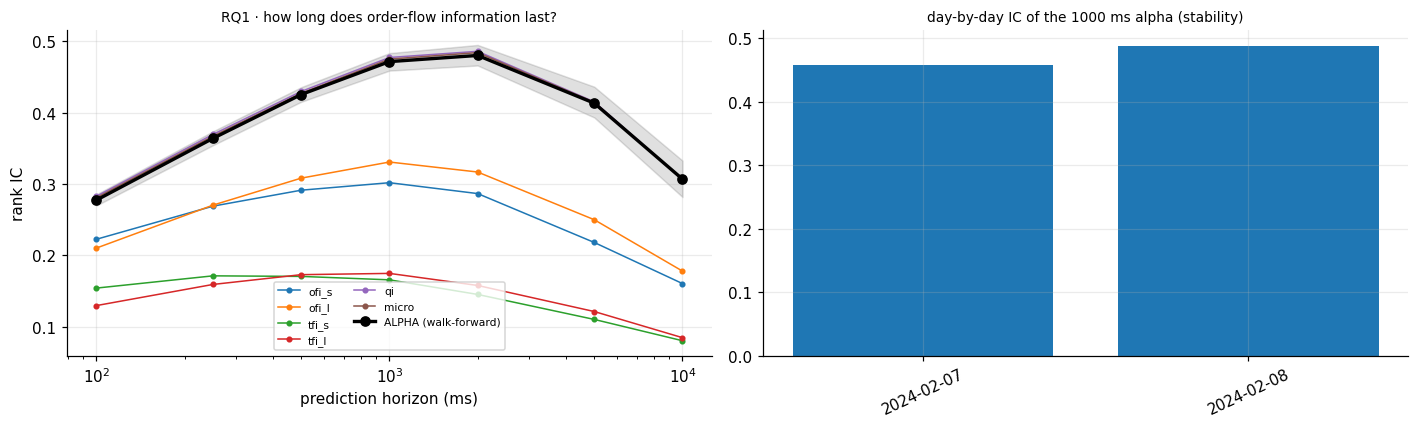

In [5]:
# ─────────────────────────────  5 · ALPHA MODEL (WALK-FORWARD)  +  SIGNAL DECAY  (RQ1)  ─────────────────────────────
H = CFG["HORIZONS_MS"]; HI = {h: i for i, h in enumerate(H)}
QS = sorted(set([0.5, 0.7, 0.8, 0.9, 0.95, 0.99, CFG["TRADE_QUANTILE"], CFG["PULL_QUANTILE"]] + CFG["PULL_QUANTILES_SENS"]))

@dataclass
class Ridge:
    mu: np.ndarray; sd: np.ndarray; coef: np.ndarray; icpt: float
    def predict(self, X):
        return self.icpt + np.clip((X - self.mu) / self.sd, -6, 6) @ self.coef

def fit_ridge(X, y, lam_rel):
    mu, sd = X.mean(0), X.std(0) + 1e-12
    Z = np.clip((X - mu) / sd, -6, 6); ym = y.mean()
    A = Z.T @ Z + lam_rel * len(Z) * np.eye(Z.shape[1])
    return Ridge(mu, sd, np.linalg.solve(A, Z.T @ (y - ym)), ym)

# For every evaluation day d and horizon h: fit ONLY on days < d, store the in-sample |alpha| quantiles
# (they become fixed trading thresholds for day d – no information from day d is used).
MODELS, ALPHA = {}, {}
for d in range(CFG["N_WARMUP"], len(DAYS)):
    train = list(range(d))
    Xtr = np.vstack([XMAT[j] for j in train])
    for h in H:
        ytr = np.concatenate([YFWD[j][:, HI[h]] for j in train])
        m = fit_ridge(Xtr, ytr, CFG["RIDGE_LAM"])
        p_in = np.abs(m.predict(Xtr))
        MODELS[(d, h)] = dict(model=m, train=train, qthr={q: float(np.quantile(p_in, q)) for q in QS})
        ALPHA[(d, h)] = m.predict(XMAT[d])

AUDIT["2 · every model is fitted on strictly earlier days than the day it scores"] = all(max(v["train"]) < d for (d, h), v in MODELS.items())
AUDIT["3 · trading thresholds come from training-sample predictions only"] = all(len(v["train"]) == d for (d, h), v in MODELS.items())

def block_ids(day_i, times):
    return day_i * 100_000 + (np.asarray(times) - DAYS[day_i].t0) // CFG["BLOCK_MS"]

def boot_mean_ci(vals, blk, n_boot=None, seed=0):
    """Moving-block bootstrap (1-minute blocks) 95 % CI for a mean; blocks respect the strong serial correlation."""
    n_boot = n_boot or CFG["BOOT"]
    u, inv = np.unique(blk, return_inverse=True)
    S = np.bincount(inv, weights=vals); N = np.bincount(inv).astype(float)
    idx = np.random.default_rng(seed).integers(0, len(u), (n_boot, len(u)))
    m = S[idx].sum(1) / N[idx].sum(1)
    return tuple(np.percentile(m, [2.5, 97.5]))

def boot_corr_ci(rx, ry, blk, n_boot=None, seed=0):
    n_boot = n_boot or CFG["BOOT"]
    u, inv = np.unique(blk, return_inverse=True)
    st = [np.bincount(inv, weights=w) for w in (np.ones_like(rx), rx, ry, rx * rx, ry * ry, rx * ry)]
    idx = np.random.default_rng(seed).integers(0, len(u), (n_boot, len(u)))
    n, sx, sy, sxx, syy, sxy = (s[idx].sum(1) for s in st)
    cov = sxy / n - (sx / n) * (sy / n)
    return tuple(np.percentile(cov / np.sqrt((sxx / n - (sx / n) ** 2) * (syy / n - (sy / n) ** 2)), [2.5, 97.5]))

def pooled(days, hi):
    Y = np.concatenate([YFWD[d][:, hi] for d in days])
    blk = np.concatenate([block_ids(d, GRID[d]) for d in days])
    return Y, blk

rows = []
for h in H:
    hi = HI[h]
    Y, blk = pooled(DEV_DAYS, hi)
    ry = stats.rankdata(Y)
    a = np.concatenate([ALPHA[(d, h)] for d in DEV_DAYS])
    for j, name in enumerate(PRED + ["ALPHA (walk-forward ridge)"]):
        x = a if name.startswith("ALPHA") else np.concatenate([XMAT[d][:, j] for d in DEV_DAYS])
        rx = stats.rankdata(x)
        ic = np.corrcoef(rx, ry)[0, 1]
        lo, hi_ci = boot_corr_ci(rx, ry, blk, n_boot=400) if name.startswith("ALPHA") else (np.nan, np.nan)
        rows.append(dict(horizon_ms=h, signal=name, IC=ic, ci_lo=lo, ci_hi=hi_ci))
IC = pd.DataFrame(rows)
IC_PIV = IC.pivot(index="signal", columns="horizon_ms", values="IC").loc[PRED + ["ALPHA (walk-forward ridge)"]]
print("Out-of-sample rank IC (Spearman) of each signal vs forward mid-price move, development days only:")
display(IC_PIV)

# out-of-sample R² and slope of the composite alpha
r2 = []
for h in H:
    Y, _ = pooled(DEV_DAYS, HI[h]); a = np.concatenate([ALPHA[(d, h)] for d in DEV_DAYS])
    r2.append(dict(horizon_ms=h, OOS_R2=1 - np.sum((Y - a) ** 2) / np.sum((Y - Y.mean()) ** 2),
                   slope=np.polyfit(a, Y, 1)[0], mean_abs_move_bps=np.mean(np.abs(Y)), mean_abs_alpha_bps=np.mean(np.abs(a))))
R2 = pd.DataFrame(r2).set_index("horizon_ms"); display(R2)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for name in PRED:
    ax[0].plot(H, IC_PIV.loc[name].values, marker="o", ms=3, lw=1, label=name)
ic_a = IC[IC.signal.str.startswith("ALPHA")]
ax[0].plot(H, ic_a.IC.values, "k-o", lw=2.2, label="ALPHA (walk-forward)")
ax[0].fill_between(H, ic_a.ci_lo.values, ic_a.ci_hi.values, color="k", alpha=0.12)
ax[0].set_xscale("log"); ax[0].set_xlabel("prediction horizon (ms)"); ax[0].set_ylabel("rank IC"); ax[0].legend(fontsize=7, ncol=2)
ax[0].set_title("RQ1 · how long does order-flow information last?" + TAG, fontsize=9)
per_day = [np.corrcoef(stats.rankdata(ALPHA[(d, CFG['ALPHA_HORIZON_MS'])]), stats.rankdata(YFWD[d][:, HI[CFG['ALPHA_HORIZON_MS']]]))[0, 1]
           for d in DEV_DAYS]
ax[1].bar([DAYS[d].date for d in DEV_DAYS], per_day); ax[1].set_title(f"day-by-day IC of the {CFG['ALPHA_HORIZON_MS']} ms alpha (stability)", fontsize=9)
ax[1].tick_params(axis="x", rotation=25)
plt.tight_layout(); savefig("02_signal_decay"); plt.show()
IC_PIV.to_csv(os.path.join(RES_DIR, "rq1_ic_by_horizon.csv")); R2.to_csv(os.path.join(RES_DIR, "rq1_oos_r2.csv"))

### How to read Section 5 (RQ1)
For each horizon the table shows the **out-of-sample** rank IC of each raw feature and of the walk-forward composite alpha; the shaded band is a block-bootstrap 95 % CI. Read the *shape*: where the composite IC peaks and how quickly it falls is the information half-life of the signal. A high IC at 100 ms that has vanished by 2 s is a very different (and much harder to trade) signal than one that persists for 10 s.

`OOS_R2` and `slope` check calibration: a slope near 1 means predicted bps ≈ realised bps; a slope far below 1 means the model over-promises. The day-by-day bars show stability — an IC that is positive on average but flips sign across days is not a signal.

*Caution:* prediction is not profit. That is the point of the next three sections.

Executable alpha of the 1000 ms signal (top 10% |alpha|), held 1000 ms, development days:


,n_signals,gross_edge_bps,ci_lo,ci_hi,spread_cost_bps,net_of_spread_bps,pct_profitable_after_spread,pct_gross_positive,breakeven_taker_fee_bps_per_side
latency_ms,,,,,,,,,
0,22706,0.3119,0.2880,0.3371,0.0243,0.2876,55.3554,57.4386,0.1438
1,22706,0.3113,0.2871,0.3355,0.0241,0.2872,55.2717,57.3329,0.1436
5,22706,0.3086,0.2843,0.3320,0.0239,0.2847,54.9106,56.9673,0.1423
10,22706,0.3054,0.2807,0.3294,0.0237,0.2818,54.4966,56.5313,0.1409
25,22706,0.2965,0.2719,0.3201,0.0240,0.2724,53.4176,55.3642,0.1362
50,22706,0.2868,0.2632,0.3107,0.0238,0.2630,52.0567,53.9769,0.1315
100,22706,0.2699,0.2483,0.2918,0.0238,0.2461,49.8855,51.7749,0.1231
250,22706,0.2332,0.2116,0.2544,0.0237,0.2096,45.1907,46.8511,0.1048
500,22706,0.1952,0.1761,0.2150,0.0235,0.1717,40.2228,41.7643,0.0859


the gross edge never halves inside the tested latency range (≤ 500 ms) – extend LATENCIES_MS to see the half-life


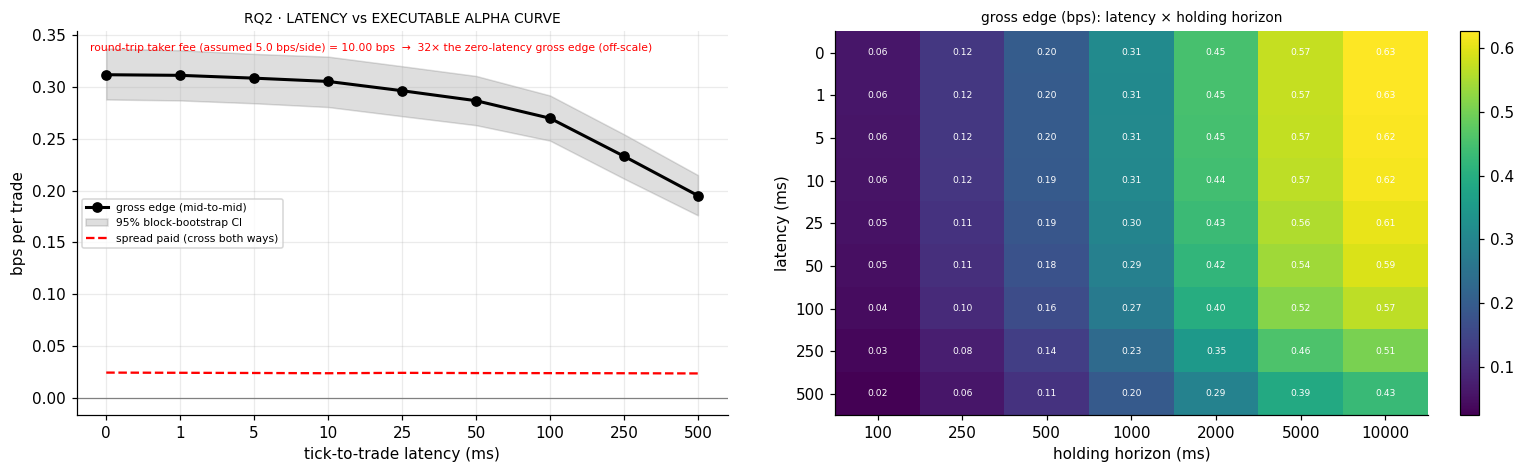

In [6]:
# ─────────────────────────────  6 · LATENCY  →  EXECUTABLE ALPHA  (RQ2)  ─────────────────────────────
H_STAR = CFG["ALPHA_HORIZON_MS"]

def taker_edges(d, L, h, q=None):
    """Directional trade taken on the alpha signal observed at t, arriving at the exchange at t+L, held h ms.
    gross = signed mid-to-mid move (bps); cost = half-spread paid on entry + half-spread on exit (bps)."""
    q = q or CFG["TRADE_QUANTILE"]
    a = ALPHA[(d, H_STAR)]; thr = MODELS[(d, H_STAR)]["qthr"][q]
    sel = np.abs(a) >= thr; ts = GRID[d][sel]; s = np.sign(a[sel])
    dd, C = DAYS[d], CACHE[d]
    m0, m1 = mid_at(dd, C, ts + L), mid_at(dd, C, ts + L + h)
    i0, i1 = np.maximum(q_index(dd, ts + L), 0), np.maximum(q_index(dd, ts + L + h), 0)
    sp0 = (dd.ask_px[i0] - dd.bid_px[i0]) / m0 * 1e4; sp1 = (dd.ask_px[i1] - dd.bid_px[i1]) / m1 * 1e4
    return ts, s * (m1 - m0) / m0 * 1e4, 0.5 * (sp0 + sp1)

def latency_table(days, lats, h, q=None):
    out = []
    for L in lats:
        g, c, b = [], [], []
        for d in days:
            ts, gross, cost = taker_edges(d, L, h, q)
            g.append(gross); c.append(cost); b.append(block_ids(d, ts))
        g, c, b = map(np.concatenate, (g, c, b))
        lo, hi = boot_mean_ci(g, b, seed=L)
        out.append(dict(latency_ms=L, n_signals=len(g), gross_edge_bps=g.mean(), ci_lo=lo, ci_hi=hi, spread_cost_bps=c.mean(),
                        net_of_spread_bps=(g - c).mean(), pct_profitable_after_spread=100 * np.mean(g - c > 0),
                        pct_gross_positive=100 * np.mean(g > 0),
                        breakeven_taker_fee_bps_per_side=(g - c).mean() / 2))
    return pd.DataFrame(out).set_index("latency_ms")

LAT = latency_table(DEV_DAYS, CFG["LATENCIES_MS"], H_STAR)
print(f"Executable alpha of the {H_STAR} ms signal (top {100*(1-CFG['TRADE_QUANTILE']):.0f}% |alpha|), held {H_STAR} ms, development days:")
display(LAT)

def half_life(lat_tbl):
    x = lat_tbl.index.values.astype(float); y = lat_tbl.gross_edge_bps.values
    if y[0] <= 0: return np.nan
    tgt = 0.5 * y[0]
    if y.min() > tgt: return np.inf
    j = np.argmax(y <= tgt)
    return float(np.interp(tgt, [y[j], y[j - 1]], [x[j], x[j - 1]])) if j > 0 else 0.0
HL = half_life(LAT)
if np.isfinite(HL):
    print(f"signal half-life (latency at which the gross edge halves): {HL:.1f} ms")
else:
    print(f"the gross edge never halves inside the tested latency range (≤ {max(CFG['LATENCIES_MS'])} ms) – extend LATENCIES_MS to see the half-life")

# edge surface: latency × holding horizon
SURF = pd.DataFrame({h: latency_table(DEV_DAYS, CFG["LATENCIES_MS"], h).gross_edge_bps for h in H})
SURF.columns.name = "hold (ms)"

fig, ax = plt.subplots(1, 2, figsize=(14, 4.4))
x = LAT.index.values; xs = np.arange(len(x))
ax[0].plot(xs, LAT.gross_edge_bps, "k-o", lw=2, label="gross edge (mid-to-mid)")
ax[0].fill_between(xs, LAT.ci_lo, LAT.ci_hi, color="k", alpha=0.13, label="95% block-bootstrap CI")
ax[0].plot(xs, LAT.spread_cost_bps, "r--", label="spread paid (cross both ways)")
g0 = LAT.gross_edge_bps.iloc[0]
ax[0].text(0.02, 0.97, f"round-trip taker fee (assumed {CFG['TAKER_FEE_BPS']} bps/side) = {2 * CFG['TAKER_FEE_BPS']:.2f} bps"
           + (f"  →  {2 * CFG['TAKER_FEE_BPS'] / g0:,.0f}× the zero-latency gross edge (off-scale)" if g0 > 0 else ""),
           transform=ax[0].transAxes, va="top", fontsize=7, color="r")
ax[0].axhline(0, color="grey", lw=0.8); ax[0].set_xticks(xs); ax[0].set_xticklabels(x)
ax[0].set_xlabel("tick-to-trade latency (ms)"); ax[0].set_ylabel("bps per trade"); ax[0].legend(fontsize=7)
ax[0].set_title("RQ2 · LATENCY vs EXECUTABLE ALPHA CURVE" + TAG, fontsize=9)
im = ax[1].imshow(SURF.values, aspect="auto", cmap="viridis")
ax[1].set_xticks(range(len(H))); ax[1].set_xticklabels(H); ax[1].set_yticks(range(len(x))); ax[1].set_yticklabels(x)
ax[1].set_xlabel("holding horizon (ms)"); ax[1].set_ylabel("latency (ms)"); ax[1].set_title("gross edge (bps): latency × holding horizon", fontsize=9)
for i in range(SURF.shape[0]):
    for j in range(SURF.shape[1]):
        ax[1].text(j, i, f"{SURF.values[i, j]:.2f}", ha="center", va="center", color="w", fontsize=6)
plt.colorbar(im, ax=ax[1], fraction=0.04); ax[1].grid(False)
plt.tight_layout(); savefig("03_latency_vs_executable_alpha"); plt.show()
LAT.to_csv(os.path.join(RES_DIR, "rq2_latency_curve.csv")); SURF.to_csv(os.path.join(RES_DIR, "rq2_latency_by_horizon.csv"))

### How to read Section 6 (RQ2) — the headline figure
A signal is observed at time *t* and an order reaches the exchange at *t + L*. The trade is entered at the mid at *t + L* and exited `hold` ms later. Reported per latency *L*:
* **gross edge** — signed mid-to-mid move in bps (the "theoretical" edge, before any cost) with a block-bootstrap CI;
* **spread cost** — half the spread on entry plus half on exit, i.e. the cost of crossing both ways;
* **net of spread**, **% profitable after spread**, and the **break-even taker fee per side**.

The left plot is the **Latency vs Executable Alpha curve**: how much of the gross edge is left after *L* ms, against the cost lines. The right heat-map shows the same edge across holding horizons — a signal whose edge lives at 100 ms holds up nowhere else. The *half-life* is the latency at which gross edge halves (interpolated); if the edge never halves within the tested range it is reported as such rather than extrapolated.

This section is deliberately a **taker** view (cross the spread). Passive execution, where adverse selection and queue position dominate, is Sections 7–9.

In [7]:
# ─────────────────────────────  7 · EVENT-DRIVEN REPLAY ENGINE + QUEUE / FILL MODEL  ─────────────────────────────
# One loop, one clock. Events are merged in time order:  trade (priority 0) → quote update (1) → strategy decision tick (2).
# The strategy only ever sees what it would have seen `sig_lag` ms ago; its orders take `exec_lat` ms to reach the book.
@njit
def simulate_mm(ev_t, ev_type, ev_i, qbp, qbq, qap, qaq, trp, trq, trs, tk_alpha, tk_bid, tk_ask,
                tick, order_qty, inv_limit, exec_lat, repeg_ticks, use_signal, pull_thr, fill_model, max_fills):
    """Post-only passive market maker: at most one resting bid and one resting ask.
    fill_model 0 conservative : joins the BACK of the displayed queue; only trades at our price advance us
               1 proportional : as 0, and cancellations ahead of us are credited pro-rata to queue position
               2 optimistic   : front of the queue – any trade at our price (or through it) fills us"""
    n = ev_t.shape[0]; nk = tk_alpha.shape[0]; eps = 0.5 * tick
    frac = 1.0 if fill_model < 2 else 0.0
    credit = fill_model >= 1
    f_t = np.empty(max_fills, np.int64); f_side = np.empty(max_fills, np.int64)
    f_px = np.empty(max_fills); f_qty = np.empty(max_fills); f_pos = np.empty(max_fills); f_mid = np.empty(max_fills)
    nf = 0
    pq_t = np.empty((2, nk + 2), np.int64); pq_px = np.empty((2, nk + 2))
    head = np.zeros(2, np.int64); tail = np.zeros(2, np.int64)
    live = np.zeros(2, np.bool_); opx = np.zeros(2); orem = np.zeros(2); qa = np.zeros(2); qunk = np.zeros(2, np.bool_)
    last_target = np.full(2, np.nan)
    live_time = np.zeros(2)
    cur_bp = np.nan; cur_bq = 0.0; cur_ap = np.nan; cur_aq = 0.0
    trd_b = 0.0; trd_a = 0.0
    pos = 0.0; last_t = -1
    n_place = 0; n_cancel = 0; n_reject = 0
    for j in range(n):
        t = ev_t[j]; typ = ev_type[j]; k = ev_i[j]
        if last_t >= 0:
            dt = t - last_t
            if live[0]: live_time[0] += dt
            if live[1]: live_time[1] += dt
        last_t = t
        # ── 1. orders/cancels whose latency has elapsed reach the exchange ──
        for s in range(2):
            while head[s] < tail[s] and pq_t[s, head[s]] <= t:
                p = pq_px[s, head[s]]; head[s] += 1
                if live[s]:
                    live[s] = False; n_cancel += 1
                if np.isnan(p):
                    continue
                if np.isnan(cur_bp):
                    n_reject += 1
                    if head[s] == tail[s]: last_target[s] = np.nan
                    continue
                crosses = (p >= cur_ap - eps) if s == 0 else (p <= cur_bp + eps)
                if crosses:                                   # post-only: would have taken liquidity → rejected
                    n_reject += 1
                    if head[s] == tail[s]: last_target[s] = np.nan
                    continue
                live[s] = True; opx[s] = p; orem[s] = order_qty; n_place += 1; qunk[s] = False; qa[s] = 0.0
                if s == 0:
                    if abs(p - cur_bp) <= eps: qa[s] = frac * cur_bq
                    elif p < cur_bp: qunk[s] = True           # resting behind the touch; depth there is unobservable on L1 data
                else:
                    if abs(p - cur_ap) <= eps: qa[s] = frac * cur_aq
                    elif p > cur_ap: qunk[s] = True
        # ── 2. the event itself ──
        if typ == 0:                                          # quote update
            nbp = qbp[k]; nbq = qbq[k]; nap = qap[k]; naq = qaq[k]
            if not np.isnan(cur_bp):
                if live[0]:
                    if nbp < opx[0] - eps:
                        qa[0] = 0.0; qunk[0] = False          # everything ahead of us has left: we ARE the touch
                    elif abs(nbp - opx[0]) <= eps:
                        if qunk[0]:
                            qa[0] = frac * nbq; qunk[0] = False
                        elif credit and abs(cur_bp - nbp) <= eps and nbq < cur_bq:
                            ce = max(0.0, (cur_bq - nbq) - trd_b)          # displayed drop not explained by trades = cancels
                            if cur_bq > 0: qa[0] -= ce * (qa[0] / cur_bq)  # pro-rata: cancels hit every queue slot equally
                            if qa[0] < 0: qa[0] = 0.0
                        if credit and qa[0] > nbq: qa[0] = nbq
                if live[1]:
                    if nap > opx[1] + eps:
                        qa[1] = 0.0; qunk[1] = False
                    elif abs(nap - opx[1]) <= eps:
                        if qunk[1]:
                            qa[1] = frac * naq; qunk[1] = False
                        elif credit and abs(cur_ap - nap) <= eps and naq < cur_aq:
                            ce = max(0.0, (cur_aq - naq) - trd_a)
                            if cur_aq > 0: qa[1] -= ce * (qa[1] / cur_aq)
                            if qa[1] < 0: qa[1] = 0.0
                        if credit and qa[1] > naq: qa[1] = naq
            cur_bp = nbp; cur_bq = nbq; cur_ap = nap; cur_aq = naq; trd_b = 0.0; trd_a = 0.0
        elif typ == 1:                                        # trade print
            px = trp[k]; qty = trq[k]; s = 1 if trs[k] > 0 else 0      # aggressor BUY lifts asks (s=1), SELL hits bids (s=0)
            if not np.isnan(cur_bp):
                if s == 0 and abs(px - cur_bp) <= eps: trd_b += qty
                elif s == 1 and abs(px - cur_ap) <= eps: trd_a += qty
            if live[s]:
                fq = 0.0
                through = (px < opx[0] - eps) if s == 0 else (px > opx[1] + eps)
                if through:
                    fq = orem[s]; qa[s] = 0.0; qunk[s] = False
                elif abs(px - opx[s]) <= eps:
                    if qunk[s]:
                        qa[s] = frac * qty; qunk[s] = False
                    if qa[s] >= qty:
                        qa[s] -= qty
                    else:
                        fq = min(orem[s], qty - qa[s]); qa[s] = 0.0
                if fq > 1e-12 and nf < max_fills:
                    sg = 1 if s == 0 else -1
                    orem[s] -= fq; pos += sg * fq
                    f_t[nf] = t; f_side[nf] = sg; f_px[nf] = opx[s]; f_qty[nf] = fq; f_pos[nf] = pos
                    f_mid[nf] = 0.5 * (cur_bp + cur_ap); nf += 1
                    if orem[s] <= 1e-12:
                        live[s] = False
                        if head[s] == tail[s]: last_target[s] = np.nan
        else:                                                 # strategy decision tick
            alpha = tk_alpha[k]
            want = np.array([pos + order_qty <= inv_limit + 1e-12, pos - order_qty >= -inv_limit - 1e-12])
            if use_signal and not np.isnan(alpha):
                if alpha > pull_thr: want[1] = False          # price about to rise → our ASK is the one that gets picked off
                elif alpha < -pull_thr: want[0] = False       # price about to fall → our BID is the one that gets picked off
            for s in range(2):
                d = np.nan
                if want[s]:
                    d = tk_bid[k] if s == 0 else tk_ask[k]
                lt = last_target[s]; submit = False
                if np.isnan(d):
                    submit = not np.isnan(lt)
                elif np.isnan(lt):
                    submit = True
                elif abs(d - lt) >= repeg_ticks * tick - eps:
                    submit = True
                if submit:
                    i = tail[s]; pq_t[s, i] = t + exec_lat; pq_px[s, i] = d; tail[s] += 1; last_target[s] = d
    return (f_t[:nf], f_side[:nf], f_px[:nf], f_qty[:nf], f_pos[:nf], f_mid[:nf], pos, live_time[0], live_time[1],
            n_place, n_cancel, n_reject)

def merge_events(q_t, tr_t, tk_t):
    """Deterministic total order: by time, then trade < quote < tick."""
    t = np.concatenate([tr_t, q_t, tk_t]); prio = np.concatenate([np.zeros(len(tr_t)), np.ones(len(q_t)), 2 * np.ones(len(tk_t))])
    typ = np.concatenate([np.ones(len(tr_t), np.int8), np.zeros(len(q_t), np.int8), 2 * np.ones(len(tk_t), np.int8)])
    idx = np.concatenate([np.arange(len(tr_t)), np.arange(len(q_t)), np.arange(len(tk_t))]).astype(np.int64)
    o = np.lexsort((prio, t))
    return t[o].astype(np.int64), typ[o], idx[o]

# ═══════════════ UNIT TESTS: hand-built scenarios with known correct answers ═══════════════
def run_scenario(quotes, trades, ticks, *, exec_lat=0, fill_model=1, use_signal=False, pull_thr=0.5, inv_limit=10.0, repeg=2):
    Q = np.array(quotes, float); T = np.array(trades, float).reshape(-1, 4); K = np.array(ticks, float)
    ev_t, ev_ty, ev_i = merge_events(Q[:, 0].astype(np.int64), T[:, 0].astype(np.int64) if len(T) else np.array([], np.int64), K[:, 0].astype(np.int64))
    r = simulate_mm(ev_t, ev_ty, ev_i, Q[:, 1], Q[:, 2], Q[:, 3], Q[:, 4], T[:, 1] if len(T) else np.zeros(0), T[:, 2] if len(T) else np.zeros(0),
                    T[:, 3].astype(np.int8) if len(T) else np.zeros(0, np.int8), K[:, 1], K[:, 2], K[:, 3],
                    0.1, 1.0, inv_limit, exec_lat, repeg, use_signal, pull_thr, fill_model, 100)
    return dict(t=r[0], side=r[1], px=r[2], qty=r[3], pos=r[6], n_place=r[9], n_cancel=r[10], n_reject=r[11])

BOOK = [(1000, 100.0, 10.0, 100.1, 8.0)]
TICK = [(1000, 0.0, 100.0, 100.1)]          # (t, alpha, bid seen, ask seen)
tests = {}
# 1 – conservative queue: 10 ahead; sells of 4, 5 leave 1 ahead; a sell of 1.5 fills 0.5 of our 1.0; a sell of 2 fills the last 0.5
r = run_scenario(BOOK, [(1100, 100.0, 4, -1), (1200, 100.0, 5, -1), (1300, 100.0, 1.5, -1), (1400, 100.0, 2, -1)], TICK, fill_model=0)
tests["queue: only trades advance us (conservative)"] = np.allclose(r["qty"], [0.5, 0.5]) and r["pos"] == 1.0 and np.all(r["side"] == 1)
# 2 – trade-through: a sell printing BELOW our bid proves the whole level is gone → full fill at OUR price
r = run_scenario(BOOK, [(1100, 99.9, 0.2, -1)], TICK, fill_model=0)
tests["trade-through fills us in full at our price"] = np.allclose(r["qty"], [1.0]) and np.allclose(r["px"], [100.0])
# 3 – latency: order live only at t=1050; a print at 1030 must not fill us, a print at 1060 must (optimistic queue)
r = run_scenario(BOOK, [(1030, 100.0, 5, -1), (1060, 100.0, 5, -1)], TICK, exec_lat=50, fill_model=2)
tests["latency: a print before our order is live cannot fill it"] = list(r["t"]) == [1060]
# 4 – optimistic: first print at our price fills immediately
r = run_scenario(BOOK, [(1100, 100.0, 0.3, -1)], TICK, fill_model=2)
tests["optimistic queue: first print at our price fills us"] = np.allclose(r["qty"], [0.3])
# 5 – displayed size drops 10→6 with no trades = 4 cancels: pro-rata model credits them, conservative does not
BOOK5 = BOOK + [(1050, 100.0, 6.0, 100.1, 8.0)]
r_p = run_scenario(BOOK5, [(1100, 100.0, 6.5, -1)], TICK, fill_model=1)
r_c = run_scenario(BOOK5, [(1100, 100.0, 6.5, -1)], TICK, fill_model=0)
tests["cancellations ahead are credited (proportional) / ignored (conservative)"] = np.allclose(r_p["qty"], [0.5]) and len(r_c["qty"]) == 0
# 6 – post-only: a bid at/above the current ask is rejected, not executed
BOOK_T = BOOK + [(1010, 100.0, 10.0, 100.1, 8.0)]            # a later book event lets the decision at t=1000 reach the exchange
r = run_scenario(BOOK_T, [], [(1000, 0.0, 100.1, 100.2)])
tests["post-only orders that would cross are rejected"] = r["n_reject"] == 1 and r["n_place"] == 1
# 7 – strategy B: alpha above the pull threshold withdraws the ASK (adverse-selection side) and keeps the BID
r = run_scenario(BOOK_T, [], [(1000, 2.0, 100.0, 100.1)], use_signal=True, pull_thr=0.5)
r0 = run_scenario(BOOK_T, [], TICK, use_signal=False)
tests["strategy B pulls the ask when alpha>thr (A keeps both sides)"] = r["n_place"] == 1 and r0["n_place"] == 2
# 8 – inventory limit: after buying up to the limit no new bid is placed (control: without the limit a new bid IS placed)
SC8 = (BOOK + [(1300, 100.0, 10.0, 100.1, 8.0)], [(1100, 100.0, 50, -1)], [(1000, 0.0, 100.0, 100.1), (1200, 0.0, 100.0, 100.1)])
r = run_scenario(*SC8, fill_model=2, inv_limit=1.0); r_free = run_scenario(*SC8, fill_model=2, inv_limit=10.0)
tests["inventory limit stops further bids (control run re-quotes)"] = r["pos"] == 1.0 and r["n_place"] == 2 and r_free["n_place"] == 3
# 9 – order placed BEHIND the touch (depth unobservable on L1): when the touch falls to our price we join behind everything displayed
r = run_scenario([(1000, 100.1, 4.0, 100.2, 4.0), (1100, 100.0, 3.0, 100.2, 4.0)],
                 [(1200, 100.0, 2.0, -1), (1300, 100.0, 1.5, -1)], [(1000, 0.0, 100.0, 100.2)], fill_model=0)
tests["order behind the touch: queue is inherited only once the touch reaches it"] = np.allclose(r["qty"], [0.5]) and list(r["t"]) == [1300]
print("REPLAY-ENGINE UNIT TESTS")
for k, v in tests.items():
    print(("  PASS  " if v else "  FAIL  ") + k)
assert all(tests.values()), "engine unit test failed – do not trust any simulated P&L"
AUDIT["4 · replay engine passes all hand-built fill / latency / queue scenarios"] = all(tests.values())

REPLAY-ENGINE UNIT TESTS
  PASS  queue: only trades advance us (conservative)
  PASS  trade-through fills us in full at our price
  PASS  latency: a print before our order is live cannot fill it
  PASS  optimistic queue: first print at our price fills us
  PASS  cancellations ahead are credited (proportional) / ignored (conservative)
  PASS  post-only orders that would cross are rejected
  PASS  strategy B pulls the ask when alpha>thr (A keeps both sides)
  PASS  inventory limit stops further bids (control run re-quotes)
  PASS  order behind the touch: queue is inherited only once the touch reaches it


### What Section 7 built — and its stated simplifications
An event-driven replay: quotes, trades and 100 ms strategy decisions are merged into one totally ordered stream (same timestamp → trade, then quote, then decision). The strategy sees the book as it was `sig_lag` ms ago; its orders and cancels arrive `exec_lat` ms after the decision, so it can still be filled while a cancel is in flight — that is exactly how latency turns into adverse selection.

**Three fill models** (the point of RQ3):
* *conservative* — join the back of the displayed queue; only trades at our price move us up;
* *proportional* — also credit cancellations ahead of us, pro-rata to queue position (displayed size drops that trades don't explain are treated as cancels);
* *optimistic* — front of the queue; any trade at or through our price fills us.
A trade printing *through* our price fills us in full at our price in every model.

**Known simplifications (state them in interviews before anyone asks):** level-1 data means depth *behind* the touch is unobservable, so an order resting behind the touch inherits its queue only when the touch reaches it; we assume our own fills are known instantly; orders are small enough to have no market impact; hidden/iceberg liquidity, self-trade prevention and queue-jumping effects are ignored; latency is a fixed number, not a distribution; inventory is marked at mid at the end of the window with no liquidation cost.

The nine **unit tests** are hand-built micro-scenarios with a known correct answer (queue advance, trade-through, latency gating, cancel crediting, post-only rejection, signal-pull direction, inventory limit, behind-the-touch queue). The notebook stops if any fails.

Baseline: latency=10 ms, queue model='proportional', maker fee=0.0 bps, quantile-0.8 pull rule, development days [2, 3]


,A · naive,B · order-flow-aware
fills,"15,330.0000","8,897.0000"
fills_per_hour,"2,572.0518","1,492.7296"
traded_qty,138.6847,82.7572
notional_usdt,"6,101,449.8223","3,643,218.6522"
gross_pnl_usdt,-365.6580,-194.4448
fees_usdt,0.0000,0.0000
net_pnl_usdt,-365.6580,-194.4448
half_spread_at_fill_bps,0.0111,0.0129
markout_1s_mean_bps,-0.3892,-0.3129
markout_5s_mean_bps,-0.5632,-0.4344


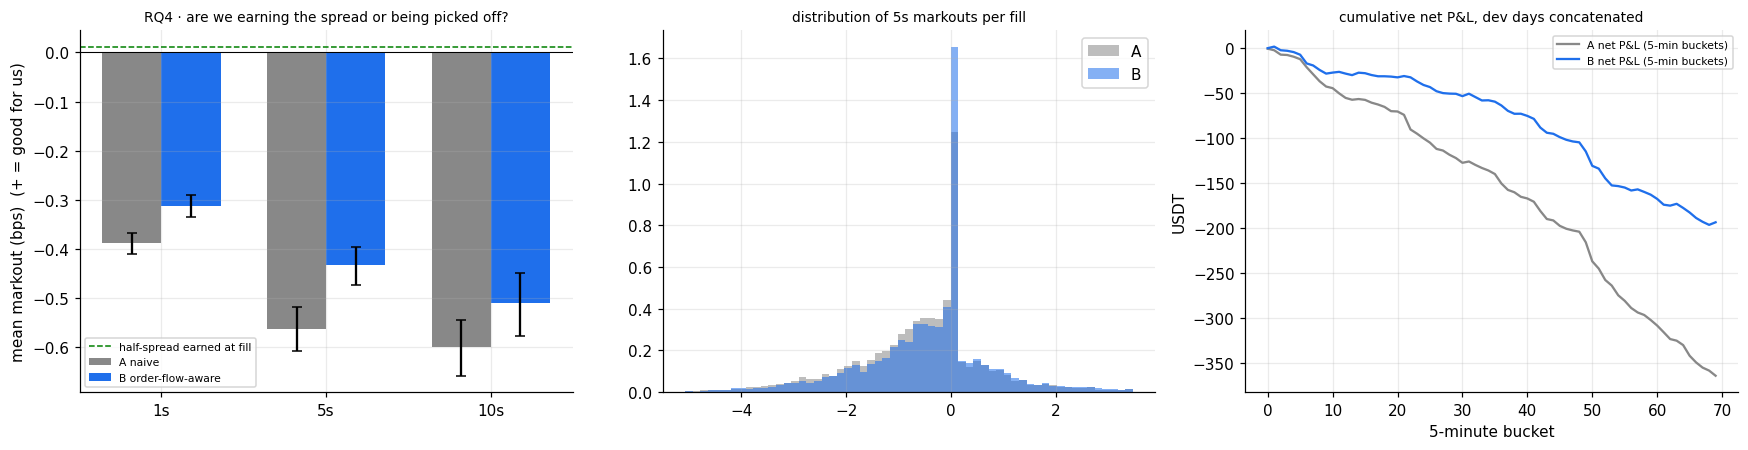

Markout difference (B − A), 95 % block-bootstrap CI – a CI that excludes 0 is the bar for saying the signal helps:


,1s,5s,10s
A mean,-0.3892,-0.5632,-0.5999
B mean,-0.3129,-0.4344,-0.5115
B − A,0.0763,0.1288,0.0883
B − A CI lo,0.0596,0.0902,0.0313
B − A CI hi,0.0929,0.1696,0.1436


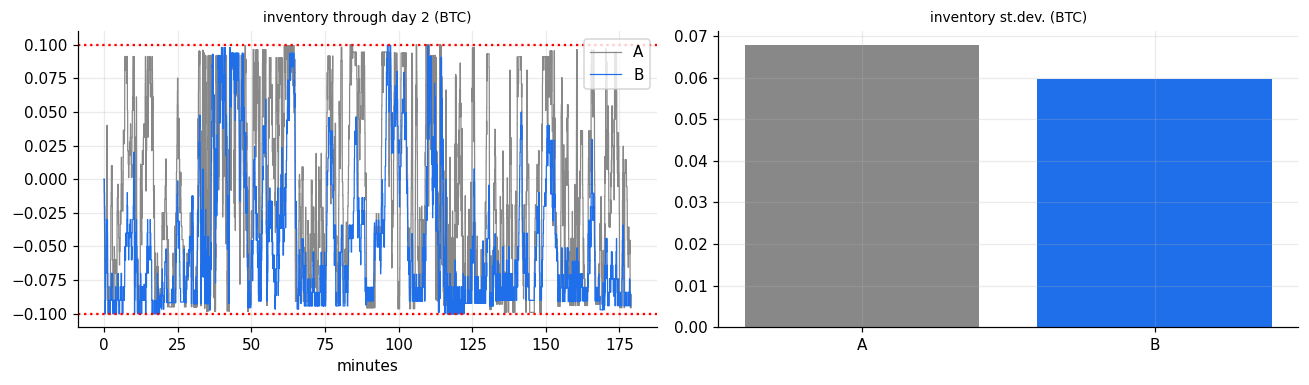

In [8]:
# ─────────────────────────────  8 · TWO MARKET MAKERS: NAIVE (A) vs ORDER-FLOW-AWARE (B)  (RQ4, RQ5)  ─────────────────────────────
#  A  quotes the touch on both sides, honours the inventory limit, nothing else.
#  B  identical to A, plus: when the alpha says the price is about to rise it withdraws its ASK; about to fall → withdraws its BID.
#  Same data, same latency, same fees, same inventory rule → any difference is caused by the signal alone.
TK_CACHE, EV_CACHE = {}, {}

def split_latency(L):
    """L = tick-to-trade latency = market-data staleness (sig_lag) + order-path delay (exec_lat)."""
    ex = L // 2
    return L - ex, ex

def tick_arrays(d, sig_lag):
    key = (d, sig_lag)
    if key not in TK_CACHE:
        ts = GRID[d] - sig_lag                                  # the strategy decides on information that is sig_lag old
        F = features_at(DAYS[d], CACHE[d], ts)
        a = MODELS[(d, H_STAR)]["model"].predict(np.column_stack([F[k] for k in PRED]))
        TK_CACHE[key] = (a, F["bid_px"], F["ask_px"])
    return TK_CACHE[key]

def run_mm(d, strategy, L, fill_model, pull_q=None):
    day = DAYS[d]
    if d not in EV_CACHE:
        EV_CACHE[d] = merge_events(day.q_t, day.tr_t, GRID[d])
    ev = EV_CACHE[d]; sig_lag, ex = split_latency(L)
    a, bs, as_ = tick_arrays(d, sig_lag)
    thr = MODELS[(d, H_STAR)]["qthr"][pull_q or CFG["PULL_QUANTILE"]]
    r = simulate_mm(ev[0], ev[1], ev[2], day.bid_px, day.bid_qty, day.ask_px, day.ask_qty, day.tr_px, day.tr_qty, day.tr_side,
                    a, bs, as_, day.tick, CFG["ORDER_QTY"], CFG["INV_LIMIT"], ex, CFG["REPEG_TICKS"], strategy == "B", thr,
                    fill_model, len(day.tr_t) + 10)
    run = dict(day=d, strategy=strategy, L=L, fill_model=fill_model, t=r[0], side=r[1], px=r[2], qty=r[3], pos_series=r[4],
               mid=r[5], pos_end=r[6], live_bid_ms=r[7], live_ask_ms=r[8], n_place=r[9], n_cancel=r[10], n_reject=r[11])
    return enrich(run)

def enrich(run):
    d = run["day"]; day, C = DAYS[d], CACHE[d]; ft = run["t"]
    for m in CFG["MARKOUT_MS"]:
        run[f"mo_{m}"] = run["side"] * (mid_at(day, C, ft + m) - run["px"]) / run["px"] * 1e4    # + = price moved in our favour after the fill
    run["capture"] = run["side"] * (run["mid"] - run["px"]) / run["px"] * 1e4                    # half-spread earned at the moment of the fill
    run["valid"] = ft + max(CFG["MARKOUT_MS"]) <= day.t1
    run["blk"] = block_ids(d, ft)
    mid_end = mid_at(day, C, np.array([GRID[d][-1]]))[0]
    run["gross_pnl"] = float(-(run["side"] * run["px"] * run["qty"]).sum() + run["pos_end"] * mid_end)     # cash + inventory marked to mid
    run["notional"] = float((run["px"] * run["qty"]).sum())
    return run

def pnl_buckets(run, fee_bps, bucket_ms=300_000):
    d = run["day"]; day, C = DAYS[d], CACHE[d]
    edges = np.arange(GRID[d][0], GRID[d][-1] + 1, bucket_ms)
    cash = np.r_[0.0, np.cumsum(-run["side"] * run["px"] * run["qty"])]; fee = np.r_[0.0, np.cumsum(fee_bps * 1e-4 * run["px"] * run["qty"])]
    pos = np.r_[0.0, run["pos_series"]]; k = np.searchsorted(run["t"], edges, side="right")
    return np.diff(cash[k] + pos[k] * mid_at(day, C, edges) - fee[k])

def inventory_stats(run):
    d = run["day"]; t0, t1 = GRID[d][0], GRID[d][-1]
    tt = np.r_[t0, np.clip(run["t"], t0, t1), t1]; pp = np.r_[0.0, run["pos_series"]]; w = np.diff(tt).astype(float)
    m = np.average(pp, weights=w) if w.sum() else 0.0
    return m, np.sqrt(np.average((pp - m) ** 2, weights=w)) if w.sum() else 0.0, np.abs(pp).max(), np.average(np.abs(pp) >= CFG["INV_LIMIT"] - 1e-9, weights=w)

def summarize(runs, fee_bps):
    cat = lambda k: np.concatenate([r[k] for r in runs]) if runs else np.array([])
    v = cat("valid").astype(bool); n = len(cat("t"))
    span_h = sum((GRID[r["day"]][-1] - GRID[r["day"]][0]) for r in runs) / 3.6e6
    notional = sum(r["notional"] for r in runs); gross = sum(r["gross_pnl"] for r in runs)
    mo = {m: cat(f"mo_{m}")[v] for m in CFG["MARKOUT_MS"]}; cap = cat("capture")[v]
    buckets = np.concatenate([pnl_buckets(r, fee_bps) for r in runs]); inv = np.array([inventory_stats(r) for r in runs])
    dd = [np.min(np.cumsum(pnl_buckets(r, fee_bps)) - np.maximum.accumulate(np.r_[0.0, np.cumsum(pnl_buckets(r, fee_bps))])[1:]) for r in runs]
    span_s = sum((GRID[r["day"]][-1] - GRID[r["day"]][0]) for r in runs) / 1000
    m5 = CFG["MARKOUT_MS"][1]
    return {"fills": n, "fills_per_hour": n / span_h, "traded_qty": float(cat("qty").sum()), "notional_usdt": notional,
            "gross_pnl_usdt": gross, "fees_usdt": fee_bps * 1e-4 * notional, "net_pnl_usdt": gross - fee_bps * 1e-4 * notional,
            "half_spread_at_fill_bps": cap.mean() if len(cap) else np.nan,
            **{f"markout_{m//1000}s_mean_bps": mo[m].mean() if len(mo[m]) else np.nan for m in mo},
            **{f"markout_{m//1000}s_median_bps": np.median(mo[m]) if len(mo[m]) else np.nan for m in mo},
            "adverse_selection_5s_bps": (cap.mean() - mo[m5].mean()) if len(cap) else np.nan,
            "net_edge_per_fill_5s_bps": (mo[m5].mean() - fee_bps) if len(cap) else np.nan,
            "breakeven_maker_fee_bps": gross / notional * 1e4 if notional else np.nan,
            "quoted_time_pct": 100 * sum(r["live_bid_ms"] + r["live_ask_ms"] for r in runs) / (2 * span_s * 1000),
            "orders_sent_per_min": sum(r["n_place"] + r["n_cancel"] for r in runs) / (span_s / 60),
            "rejected_post_only": sum(r["n_reject"] for r in runs),
            "inventory_mean_btc": inv[:, 0].mean(), "inventory_std_btc": inv[:, 1].mean(), "inventory_max_abs_btc": inv[:, 2].max(),
            "pct_time_at_inv_limit": 100 * inv[:, 3].mean(), "inventory_turnover_x": float(cat("qty").sum()) / CFG["INV_LIMIT"] / len(runs),
            "sharpe_5min_annualised(24/7 extrapolation)": buckets.mean() / buckets.std() * np.sqrt(105_120) if buckets.std() > 0 else np.nan,
            "pnl_5min_p05_usdt": np.percentile(buckets, 5), "worst_5min_pnl_usdt": buckets.min(), "max_drawdown_usdt": min(dd)}

def boot_markout(runs_a, runs_b, m, n_boot=None, seed=1):
    """Block-bootstrap CIs for mean markout of A, of B and of (B − A), resampling whole 1-minute blocks jointly."""
    n_boot = n_boot or CFG["BOOT"]
    col = f"mo_{m}"
    ba = np.concatenate([r["blk"][r["valid"]] for r in runs_a]); va = np.concatenate([r[col][r["valid"]] for r in runs_a])
    bb = np.concatenate([r["blk"][r["valid"]] for r in runs_b]); vb = np.concatenate([r[col][r["valid"]] for r in runs_b])
    u = np.unique(np.concatenate([ba, bb])); ia = np.searchsorted(u, ba); ib = np.searchsorted(u, bb)
    Sa, Na = np.bincount(ia, va, len(u)), np.bincount(ia, minlength=len(u)).astype(float)
    Sb, Nb = np.bincount(ib, vb, len(u)), np.bincount(ib, minlength=len(u)).astype(float)
    idx = np.random.default_rng(seed).integers(0, len(u), (n_boot, len(u)))
    ma = Sa[idx].sum(1) / np.maximum(Na[idx].sum(1), 1); mb = Sb[idx].sum(1) / np.maximum(Nb[idx].sum(1), 1)
    q = lambda x: tuple(np.percentile(x, [2.5, 97.5]))
    return dict(A=(va.mean(), *q(ma)), B=(vb.mean(), *q(mb)), diff=(vb.mean() - va.mean(), *q(mb - ma)))

# ───────────────────── baseline run on the development days ─────────────────────
L0, FM0, FEE0 = CFG["BASE_LATENCY_MS"], BASE_QUEUE_MODEL, CFG["MAKER_FEE_BPS"]
BASE_RUNS = {s: [run_mm(d, s, L0, FM0) for d in DEV_DAYS] for s in ("A", "B")}

# audit part 3: the stale-information path really is stale (truncate the future, recompute the decision-tick alpha)
def audit_tick_alpha(n_check=15, L=100):
    d = DEV_DAYS[0]; sig_lag, _ = split_latency(L); a, _, _ = tick_arrays(d, sig_lag); worst = 0.0
    for j in RNG.choice(len(GRID[d]), n_check, replace=False):
        t_info = GRID[d][j] - sig_lag; dt_ = truncate_day(DAYS[d], t_info); F = features_at(dt_, build_cache(dt_), np.array([t_info]))
        p = MODELS[(d, H_STAR)]["model"].predict(np.array([[F[k][0] for k in PRED]]))[0]
        worst = max(worst, abs(p - a[j]) / (1e-9 + abs(a[j])))
    return worst
AUDIT["5 · the alpha a strategy acts on at decision time t is computed from data ≤ t − sig_lag only"] = audit_tick_alpha() < 1e-6

SUM = pd.DataFrame({f"{s} · {'naive' if s == 'A' else 'order-flow-aware'}": summarize(BASE_RUNS[s], FEE0) for s in ("A", "B")})
print(f"Baseline: latency={L0} ms, queue model='{QUEUE_MODELS[FM0]}', maker fee={FEE0} bps, quantile-{CFG['PULL_QUANTILE']} pull rule, development days {DEV_DAYS}{TAG}")
display(SUM)
SUM.to_csv(os.path.join(RES_DIR, "rq4_rq5_baseline_summary.csv"))

# ───────────────────── adverse selection (RQ4) ─────────────────────
BM = {m: boot_markout(BASE_RUNS["A"], BASE_RUNS["B"], m) for m in CFG["MARKOUT_MS"]}
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
w = 0.36; xs = np.arange(len(CFG["MARKOUT_MS"]))
for k, (s, col) in enumerate((("A", "#888"), ("B", "#1f6feb"))):
    mean = [BM[m][s][0] for m in CFG["MARKOUT_MS"]]; err = [[BM[m][s][0] - BM[m][s][1] for m in CFG["MARKOUT_MS"]], [BM[m][s][2] - BM[m][s][0] for m in CFG["MARKOUT_MS"]]]
    ax[0].bar(xs + (k - 0.5) * w, mean, w, yerr=err, color=col, label={"A": "A naive", "B": "B order-flow-aware"}[s], capsize=3)
cap_mean = SUM.loc["half_spread_at_fill_bps"].mean()
ax[0].axhline(cap_mean, color="g", ls="--", lw=1, label="half-spread earned at fill"); ax[0].axhline(0, color="k", lw=0.7)
ax[0].set_xticks(xs); ax[0].set_xticklabels([f"{m//1000}s" for m in CFG["MARKOUT_MS"]]); ax[0].set_ylabel("mean markout (bps)  (+ = good for us)")
ax[0].set_title("RQ4 · are we earning the spread or being picked off?" + TAG, fontsize=9); ax[0].legend(fontsize=7)
m5 = CFG["MARKOUT_MS"][1]
for s, col in (("A", "#888"), ("B", "#1f6feb")):
    x = np.concatenate([r[f"mo_{m5}"][r["valid"]] for r in BASE_RUNS[s]])
    ax[1].hist(x, bins=np.linspace(*np.percentile(np.concatenate([np.concatenate([r[f"mo_{m5}"][r["valid"]] for r in BASE_RUNS[k]]) for k in "AB"]), [1, 99]), 60),
               alpha=0.55, color=col, label=s, density=True)
ax[1].set_title(f"distribution of {m5//1000}s markouts per fill", fontsize=9); ax[1].legend()
for s, col in (("A", "#888"), ("B", "#1f6feb")):
    ax[2].plot(np.cumsum(np.concatenate([pnl_buckets(r, FEE0) for r in BASE_RUNS[s]])), color=col, label=f"{s} net P&L (5-min buckets)")
ax[2].set_title("cumulative net P&L, dev days concatenated", fontsize=9); ax[2].legend(fontsize=7); ax[2].set_xlabel("5-minute bucket"); ax[2].set_ylabel("USDT")
plt.tight_layout(); savefig("04_adverse_selection"); plt.show()

tbl = pd.DataFrame({f"{m//1000}s": {"A mean": BM[m]["A"][0], "B mean": BM[m]["B"][0], "B − A": BM[m]["diff"][0], "B − A  CI lo": BM[m]["diff"][1], "B − A  CI hi": BM[m]["diff"][2]} for m in CFG["MARKOUT_MS"]})
print("Markout difference (B − A), 95 % block-bootstrap CI – a CI that excludes 0 is the bar for saying the signal helps:")
display(tbl); tbl.to_csv(os.path.join(RES_DIR, "rq4_markout_difference.csv"))

# inventory picture
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
for s, col in (("A", "#888"), ("B", "#1f6feb")):
    r = BASE_RUNS[s][0]; d = r["day"]
    ax[0].step((np.r_[GRID[d][0], r["t"]] - GRID[d][0]) / 60000, np.r_[0, r["pos_series"]], where="post", color=col, lw=0.8, label=s)
ax[0].axhline(CFG["INV_LIMIT"], color="r", ls=":"); ax[0].axhline(-CFG["INV_LIMIT"], color="r", ls=":")
ax[0].set_title(f"inventory through day {DEV_DAYS[0]} (BTC)", fontsize=9); ax[0].set_xlabel("minutes"); ax[0].legend()
ax[1].bar(["A", "B"], [SUM.iloc[:, 0].loc["inventory_std_btc"], SUM.iloc[:, 1].loc["inventory_std_btc"]], color=["#888", "#1f6feb"])
ax[1].set_title("inventory st.dev. (BTC)", fontsize=9)
plt.tight_layout(); savefig("05_inventory"); plt.show()

### How to read Section 8 (RQ4, RQ5)
**Strategy A** joins the touch on both sides. **Strategy B** is A plus one rule: if the alpha says the price is *about to rise*, it withdraws its **ask** (a rising market lifts your ask just before it goes up — that is the adverse fill); if it says *about to fall*, it withdraws its **bid**. Same data, latency, fees and inventory limit, so any difference is caused by the signal alone.

*Direction matters:* on upward pressure you pull the **ask**, not the bid. (A common slip is to reverse this.)

The bar chart compares mean markouts at 1 / 5 / 10 s with the half-spread earned at the fill (dashed green). If the markout bars sit below zero by more than the green line, you are giving back more than you earn: **you are being picked off**. The table beneath gives the B − A markout difference with a 95 % block-bootstrap CI; a CI that includes zero means the data do not show that the signal helps. The summary table also reports fill rate, quoted-time share, inventory mean / st.dev. / max, time at the inventory limit, drawdown, tail losses, and an *indicative* annualised Sharpe on 5-minute buckets (a 24/7 extrapolation from a few short sessions — treat it as a rough scale, not a forecast).

Reducing adverse selection is not free: check whether B pays for better markouts with fewer fills or less time quoted.

RQ3 · same strategies, same data, latency 10 ms – only the fill assumption changes:


fills  fills_per_hour  gross_pnl   net_pnl  half_spread_bps  markout_5s_bps  adverse_sel_5s_bps  breakeven_fee_bps  inv_std
strategy queue_model                                                                                                                              
A        conservative   9310      1,562.0223  -310.9837 -310.9837           0.0085         -0.7925              0.8011            -0.7930   0.0678
         proportional  15330      2,572.0518  -365.6580 -365.6580           0.0111         -0.5632              0.5743            -0.5993   0.0678
         optimistic    71926     12,067.6709  -260.3863 -260.3863           0.0116         -0.0838              0.0954            -0.1038   0.0688
B        conservative   4227        709.2017  -142.0964 -142.0964           0.0121         -0.7427              0.7548            -0.7789   0.0506
         proportional   8897      1,492.7296  -194.4448 -194.4448           0.0129         -0.4344              0.4473            -0.5337   0.0596
         optimistic    62318     10,455.6504   -38.3977  -38.3977           0.0117          0.0087              0.0031            -0.0178   0.0664

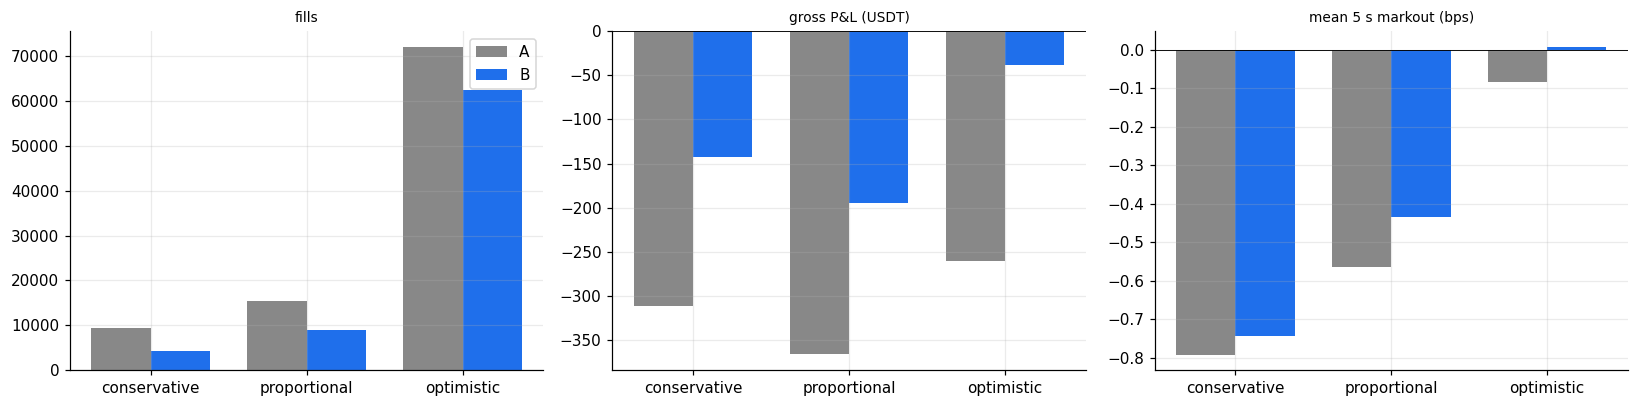

,q,fills,fills_per_hour,gross_pnl,net_pnl,half_spread_bps,markout_5s_bps,adverse_sel_5s_bps,breakeven_fee_bps,inv_std
variant,,,,,,,,,,
A (never pulls),NaN,15330,"2,572.0518",-365.6580,-365.6580,0.0111,-0.5632,0.5743,-0.5993,0.0678
B q=0.5,0.5000,4903,822.6203,-103.2724,-103.2724,0.0149,-0.3464,0.3613,-0.5027,0.0537
B q=0.7,0.7000,7346,"1,232.5044",-152.7396,-152.7396,0.0134,-0.3965,0.4099,-0.5025,0.0596
B q=0.8,0.8000,8897,"1,492.7296",-194.4448,-194.4448,0.0129,-0.4344,0.4473,-0.5337,0.0596
B q=0.9,0.9000,11702,"1,963.3496",-263.7865,-263.7865,0.0125,-0.5052,0.5177,-0.5612,0.0676
B q=0.95,0.9500,13228,"2,219.3803",-304.1125,-304.1125,0.0116,-0.5305,0.5421,-0.5765,0.0673


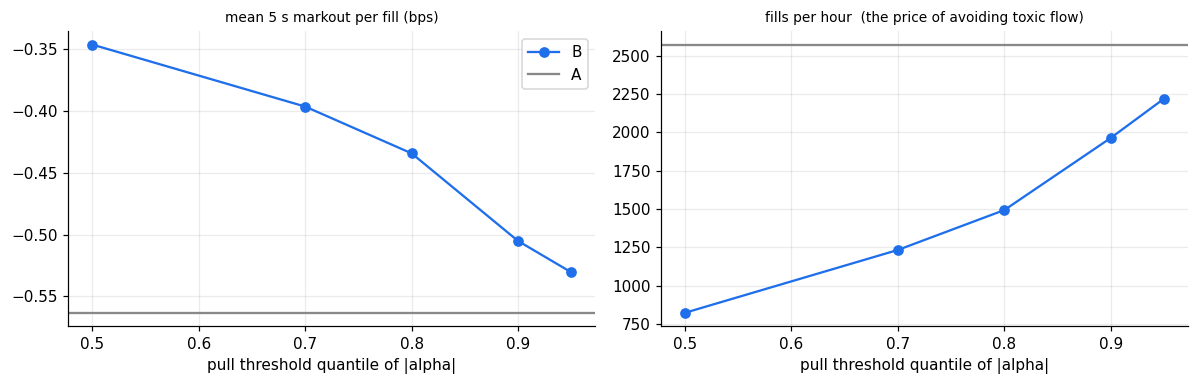

594 grid rows (54 simulations) in 13s
NET P&L (USDT) at maker fee = 0.0 bps:


latency_ms                  0         1         5         10        25        50        100       250       500
strategy queue_model                                                                                           
A        conservative -338.3990 -337.8026 -323.5207 -310.9837 -285.1917 -257.1613 -235.8325 -212.9727 -178.5225
         optimistic   -281.5301 -279.6244 -269.6369 -260.3863 -240.8231 -230.6882 -212.8208 -186.1109 -140.0018
         proportional -394.9943 -393.3324 -379.1793 -365.6580 -343.5374 -318.5820 -294.1213 -244.9951 -206.9345
B        conservative -147.7468 -150.0348 -148.7028 -142.0964 -149.6368 -149.4881 -140.9415 -142.6565 -138.5650
         optimistic    -39.0413  -38.0147  -36.8388  -38.3977  -39.0914  -47.3683  -40.9432  -72.5559  -64.3017
         proportional -202.5451 -199.1430 -197.2410 -194.4448 -192.2751 -191.8182 -183.3820 -168.7812 -166.8515

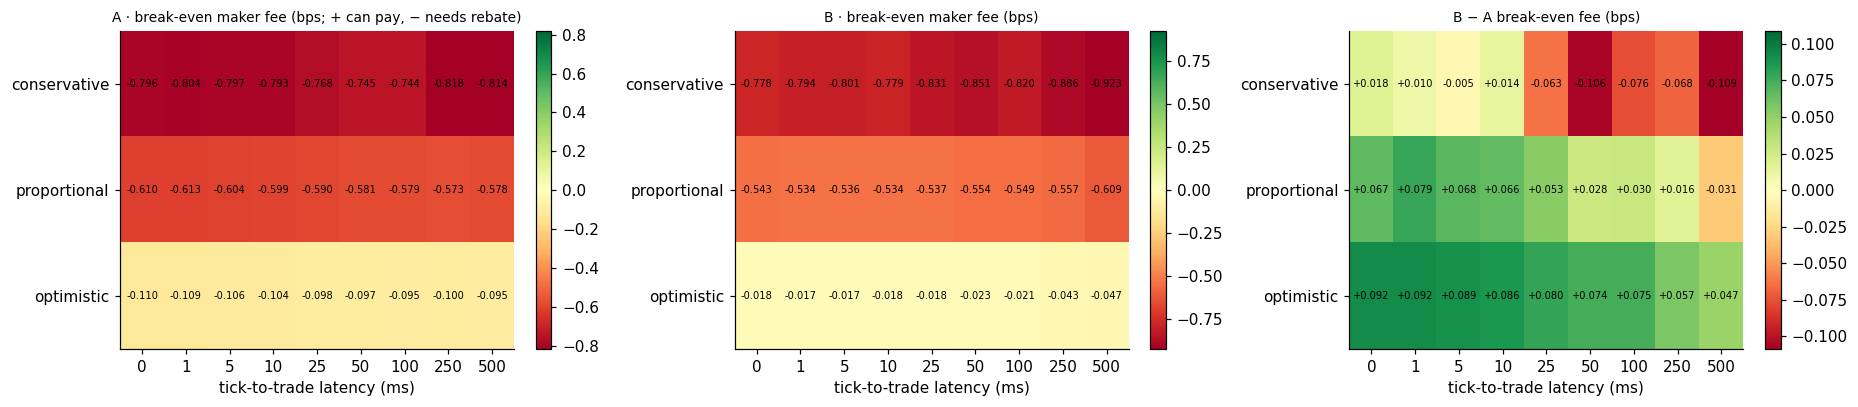

BREAK-EVEN LATENCY – the latency at which net P&L crosses zero, per maker fee (bps):


fee -0.50               fee -0.20               fee -0.10               fee -0.05               fee +0.00               fee +0.05  \
strategy queue_model                                                                                                                                                    
A        conservative  never (≤0 at lowest L)  never (≤0 at lowest L)  never (≤0 at lowest L)  never (≤0 at lowest L)  never (≤0 at lowest L)  never (≤0 at lowest L)   
         proportional  never (≤0 at lowest L)  never (≤0 at lowest L)  never (≤0 at lowest L)  never (≤0 at lowest L)  never (≤0 at lowest L)  never (≤0 at lowest L)   
         optimistic                   >500 ms                 >500 ms  never (≤0 at lowest L)  never (≤0 at lowest L)  never (≤0 at lowest L)  never (≤0 at lowest L)   
B        conservative  never (≤0 at lowest L)  never (≤0 at lowest L)  never (≤0 at lowest L)  never (≤0 at lowest L)  never (≤0 at lowest L)  never (≤0 at lowest L)   
         proportional  never (≤0 at lowest L)  never (≤0 at lowest L)  never (≤0 at lowest L)  never (≤0 at lowest L)  never (≤0 at lowest L)  never (≤0 at lowest L)   
         optimistic                   >500 ms                 >500 ms                 >500 ms                 >500 ms  never (≤0 at lowest L)  never (≤0 at lowest L)   

                                    fee +0.10               fee +0.20               fee +0.50               fee +1.00               fee +2.00  
strategy queue_model                                                                                                                           
A        conservative  never (≤0 at lowest L)  never (≤0 at lowest L)  never (≤0 at lowest L)  never (≤0 at lowest L)  never (≤0 at lowest L)  
         proportional  never (≤0 at lowest L)  never (≤0 at lowest L)  never (≤0 at lowest L)  never (≤0 at lowest L)  never (≤0 at lowest L)  
         optimistic    never (≤0 at lowest L)  never (≤0 at lowest L)  never (≤0 at lowest L)  never (≤0 at lowest L)  never (≤0 at lowest L)  
B        conservative  never (≤0 at lowest L)  never (≤0 at lowest L)  never (≤0 at lowest L)  never (≤0 at lowest L)  never (≤0 at lowest L)  
         proportional  never (≤0 at lowest L)  never (≤0 at lowest L)  never (≤0 at lowest L)  never (≤0 at lowest L)  never (≤0 at lowest L)  
         optimistic    never (≤0 at lowest L)  never (≤0 at lowest L)  never (≤0 at lowest L)  never (≤0 at lowest L)  never (≤0 at lowest L)

In [9]:
# ─────────────────────────────  9 · QUEUE-MODEL SENSITIVITY (RQ3) · PULL-RULE SENSITIVITY · BREAK-EVEN GRID (RQ6)  ─────────────────────────────
def tidy(sm, **kw):
    return dict(kw, fills=sm["fills"], fills_per_hour=sm["fills_per_hour"], gross_pnl=sm["gross_pnl_usdt"], net_pnl=sm["net_pnl_usdt"],
                half_spread_bps=sm["half_spread_at_fill_bps"], markout_5s_bps=sm["markout_5s_mean_bps"],
                adverse_sel_5s_bps=sm["adverse_selection_5s_bps"], breakeven_fee_bps=sm["breakeven_maker_fee_bps"],
                inv_std=sm["inventory_std_btc"])

# ---- RQ3 · how much of the P&L is just the fill assumption? ----
rows = []
for s in "AB":
    for fm in QUEUE_MODELS:
        rows.append(tidy(summarize([run_mm(d, s, L0, fm) for d in DEV_DAYS], FEE0), strategy=s, queue_model=QUEUE_MODELS[fm]))
QSENS = pd.DataFrame(rows)
print(f"RQ3 · same strategies, same data, latency {L0} ms – only the fill assumption changes:{TAG}")
display(QSENS.set_index(["strategy", "queue_model"]))
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8)); qn = list(QUEUE_MODELS.values())
for k, (col, ttl) in enumerate((("fills", "fills"), ("gross_pnl", "gross P&L (USDT)"), ("markout_5s_bps", "mean 5 s markout (bps)"))):
    for j, (s, c) in enumerate((("A", "#888"), ("B", "#1f6feb"))):
        ax[k].bar(np.arange(3) + (j - 0.5) * 0.38, QSENS[QSENS.strategy == s][col].values, 0.38, color=c, label=s)
    ax[k].set_xticks(range(3)); ax[k].set_xticklabels(qn); ax[k].set_title(ttl + TAG, fontsize=9); ax[k].axhline(0, color="k", lw=0.6)
ax[0].legend(); plt.tight_layout(); savefig("06_queue_sensitivity"); plt.show()
QSENS.to_csv(os.path.join(RES_DIR, "rq3_queue_sensitivity.csv"), index=False)

# ---- pull-rule sensitivity (the headline uses q = PULL_QUANTILE fixed BEFORE looking at results; this shows how fragile that choice is) ----
rows = [tidy(summarize(BASE_RUNS["A"], FEE0), variant="A (never pulls)", q=np.nan)]
for q in CFG["PULL_QUANTILES_SENS"]:
    rows.append(tidy(summarize([run_mm(d, "B", L0, FM0, pull_q=q) for d in DEV_DAYS], FEE0), variant=f"B q={q}", q=q))
PSENS = pd.DataFrame(rows); display(PSENS.set_index("variant"))
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(PSENS.q[1:], PSENS.markout_5s_bps[1:], "o-", color="#1f6feb", label="B"); ax[0].axhline(PSENS.markout_5s_bps[0], color="#888", label="A")
ax[0].set_xlabel("pull threshold quantile of |alpha|"); ax[0].set_title("mean 5 s markout per fill (bps)" + TAG, fontsize=9); ax[0].legend()
ax[1].plot(PSENS.q[1:], PSENS.fills_per_hour[1:], "o-", color="#1f6feb"); ax[1].axhline(PSENS.fills_per_hour[0], color="#888")
ax[1].set_xlabel("pull threshold quantile of |alpha|"); ax[1].set_title("fills per hour  (the price of avoiding toxic flow)", fontsize=9)
plt.tight_layout(); savefig("07_pull_rule_sensitivity"); plt.show()
PSENS.to_csv(os.path.join(RES_DIR, "rq5_pull_rule_sensitivity.csv"), index=False)

# ---- RQ6 · the break-even grid: latency × queue assumption × maker fee × strategy ----
t = time.time(); rows = []
for s in "AB":
    for fm in QUEUE_MODELS:
        for L in CFG["LATENCIES_MS"]:
            runs = [run_mm(d, s, L, fm) for d in DEV_DAYS]
            gross = sum(r["gross_pnl"] for r in runs); notional = sum(r["notional"] for r in runs); nfill = sum(len(r["t"]) for r in runs)
            v = np.concatenate([r["valid"] for r in runs]).astype(bool); mo5 = np.concatenate([r[f"mo_{CFG['MARKOUT_MS'][1]}"] for r in runs])[v]
            for fee in CFG["FEE_GRID_BPS"]:
                b = np.concatenate([pnl_buckets(r, fee) for r in runs])
                rows.append(dict(strategy=s, queue_model=QUEUE_MODELS[fm], latency_ms=L, maker_fee_bps=fee, fills=nfill,
                                 gross_pnl=gross, net_pnl=gross - fee * 1e-4 * notional,
                                 sharpe_5min_ann=b.mean() / b.std() * np.sqrt(105_120) if b.std() > 0 else np.nan,
                                 breakeven_fee_bps=gross / notional * 1e4 if notional else np.nan,
                                 markout_5s_bps=mo5.mean() if len(mo5) else np.nan))
GRID_DF = pd.DataFrame(rows)
print(f"{len(GRID_DF):,} grid rows ({len(GRID_DF)//len(CFG['FEE_GRID_BPS'])} simulations) in {time.time()-t:,.0f}s")
GRID_DF.to_csv(os.path.join(RES_DIR, "rq6_breakeven_grid.csv"), index=False)
base_tbl = GRID_DF[np.isclose(GRID_DF.maker_fee_bps, FEE0)].pivot_table(index=["strategy", "queue_model"], columns="latency_ms", values="net_pnl")
print(f"NET P&L (USDT) at maker fee = {FEE0} bps:{TAG}"); display(base_tbl)

fig, ax = plt.subplots(1, 3, figsize=(17, 3.8))
def heat(a, M, title, fmt="{:.3f}", cmap="RdYlGn", center=True):
    v = np.nanmax(np.abs(M)) or 1
    im = a.imshow(M, aspect="auto", cmap=cmap, vmin=-v if center else None, vmax=v if center else None)
    a.set_xticks(range(len(CFG["LATENCIES_MS"]))); a.set_xticklabels(CFG["LATENCIES_MS"]); a.set_yticks(range(3)); a.set_yticklabels(qn)
    a.set_xlabel("tick-to-trade latency (ms)"); a.set_title(title, fontsize=9); a.grid(False)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            a.text(j, i, fmt.format(M[i, j]), ha="center", va="center", fontsize=6.5)
    plt.colorbar(im, ax=a, fraction=0.04)
BE = {s: GRID_DF[(GRID_DF.strategy == s) & np.isclose(GRID_DF.maker_fee_bps, FEE0)].pivot(index="queue_model", columns="latency_ms", values="breakeven_fee_bps").loc[qn] for s in "AB"}
heat(ax[0], BE["A"].values, "A · break-even maker fee (bps; + can pay, − needs rebate)" + TAG)
heat(ax[1], BE["B"].values, "B · break-even maker fee (bps)")
heat(ax[2], (BE["B"] - BE["A"]).values, "B − A break-even fee (bps)", fmt="{:+.3f}")
plt.tight_layout(); savefig("08_breakeven_fee_grid"); plt.show()

def break_even_latency(sub):
    L = sub.latency_ms.values; y = sub.net_pnl.values
    if y[0] <= 0: return "never (≤0 at lowest L)"
    if y[-1] > 0: return f">{L[-1]} ms"
    j = np.argmax(y <= 0)
    return f"{np.interp(0, [y[j], y[j - 1]], [L[j], L[j - 1]]):.0f} ms"
bel = []
for s in "AB":
    for qm in qn:
        row = dict(strategy=s, queue_model=qm)
        for fee in CFG["FEE_GRID_BPS"]:
            row[f"fee {fee:+.2f}"] = break_even_latency(GRID_DF[(GRID_DF.strategy == s) & (GRID_DF.queue_model == qm) & np.isclose(GRID_DF.maker_fee_bps, fee)].sort_values("latency_ms"))
        bel.append(row)
BEL = pd.DataFrame(bel).set_index(["strategy", "queue_model"])
print("BREAK-EVEN LATENCY – the latency at which net P&L crosses zero, per maker fee (bps):"); display(BEL)
BEL.to_csv(os.path.join(RES_DIR, "rq6_breakeven_latency.csv"))

### How to read Section 9 (RQ3, RQ5, RQ6)
1. **Queue sensitivity (RQ3).** Same strategy, same data — only the fill assumption changes. If P&L flips sign between *conservative* and *optimistic*, the simulator cannot tell you whether the strategy makes money; say so.
2. **Pull-rule sensitivity.** `PULL_QUANTILE` was fixed in advance; this shows what a different choice would have done to markouts and fill count. A result that only works at one threshold is not robust.
3. **Break-even grid (RQ6).** For every strategy × queue model × latency we compute gross P&L and traded notional. Because a maker fee is linear in notional, the **break-even fee** is exact (`gross / notional`) — no fee grid needed to find it. The heat-maps show it (green = a fee can be paid, red = a rebate is needed); the last table gives the **break-even latency** (where net P&L crosses zero) for each fee.

*Reading the fee scale:* compare the break-even fee with the tick in bps from Section 3 and with the fee schedule you actually face. On a tick-constrained instrument the break-even fee can be a small fraction of a bp.

(a) Out-of-sample IC of the alpha inside each regime:


IC                   n             
bucket                         high    low         high          low
regime                                                              
spread (>1 tick = wide)      0.4883 0.4576 107,414.0000 107,156.0000
trade intensity (2 s)        0.5133 0.3917 105,700.0000 108,870.0000
trend strength (|60 s move|) 0.4839 0.4589 104,667.0000 109,903.0000
volatility (5 s realised)    0.5039 0.4182 105,355.0000 109,215.0000
|queue imbalance|            0.5609 0.1507 116,518.0000  98,052.0000

(b) Mean 5 s markout per fill (bps) by regime at fill time – where is passive quoting most toxic?


fills_A  fills_B  markout_A  markout_B  B_minus_A
regime                       bucket                                                   
volatility (5 s realised)    low        5188     4010    -0.4170    -0.3537     0.0634
                             high      10140     4886    -0.6380    -0.5006     0.1374
spread (>1 tick = wide)      low        6356     3567    -0.4993    -0.3776     0.1216
                             high       8972     5329    -0.6085    -0.4724     0.1361
trade intensity (2 s)        low        4086     3208    -0.3505    -0.2835     0.0670
                             high      11242     5688    -0.6405    -0.5195     0.1210
|queue imbalance|            low        4639     4095    -0.2685    -0.2702    -0.0017
                             high      10689     4801    -0.6911    -0.5744     0.1167
trend strength (|60 s move|) low        6698     3719    -0.5121    -0.4011     0.1110
                             high       8630     5177    -0.6029    -0.4583     0.1446

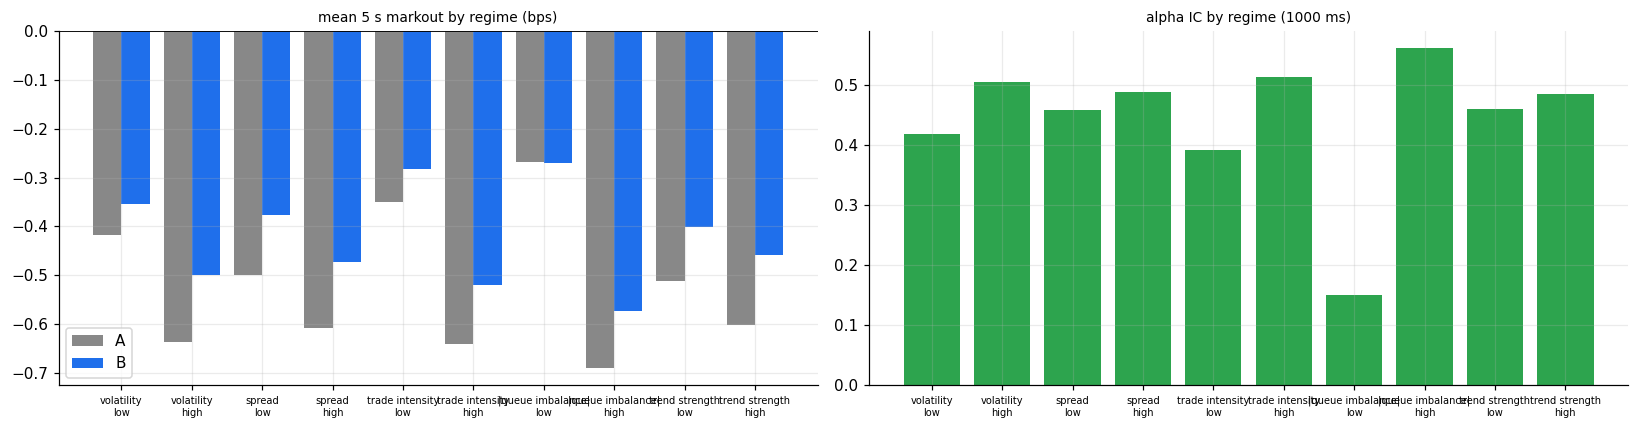

In [10]:
# ─────────────────────────────  10 · REGIME ANALYSIS: WHEN DOES ORDER-FLOW ALPHA WORK, AND WHEN IS MARKET MAKING MOST EXPOSED?  ─────────────────────────────
def regime_mask(F, var):
    """(low, high) boolean masks; cut-offs are the warm-up medians fixed in Section 4."""
    x = F[var]; c = REGIME_CUT[var]
    return (x <= c), (x > c)

LBL = {"vol": "volatility (5 s realised)", "spread_ticks": "spread (>1 tick = wide)", "intensity": "trade intensity (2 s)",
       "abs_qi": "|queue imbalance|", "trend": "trend strength (|60 s move|)"}
MIN_N = 200
# (a) predictive power of the alpha by regime
rows = []
for var in REGIME_VARS:
    for name, sel in zip(("low", "high"), (0, 1)):
        a_, y_, n = [], [], 0
        for d in DEV_DAYS:
            m = regime_mask(FEAT[d], var)[sel]
            a_.append(ALPHA[(d, H_STAR)][m]); y_.append(YFWD[d][m, HI[H_STAR]])
        a_, y_ = np.concatenate(a_), np.concatenate(y_)
        rows.append(dict(regime=LBL[var], bucket=name, n=len(a_), IC=np.corrcoef(stats.rankdata(a_), stats.rankdata(y_))[0, 1] if len(a_) >= MIN_N else np.nan,
                         mean_abs_move_bps=np.abs(y_).mean() if len(a_) else np.nan))
REG_IC = pd.DataFrame(rows)
print("(a) Out-of-sample IC of the alpha inside each regime:" + TAG); display(REG_IC.pivot(index="regime", columns="bucket", values=["IC", "n"]))

# (b) adverse selection of A and B by regime at the moment of the fill
def fills_with_regime(runs):
    parts = []
    for r in runs:
        d = r["day"]; F = features_at(DAYS[d], CACHE[d], r["t"]); v = r["valid"]
        parts.append(pd.DataFrame({**{var: F[var][v] for var in REGIME_VARS}, "mo5": r[f"mo_{CFG['MARKOUT_MS'][1]}"][v]}))
    return pd.concat(parts, ignore_index=True)
FA, FB = fills_with_regime(BASE_RUNS["A"]), fills_with_regime(BASE_RUNS["B"])
rows = []
for var in REGIME_VARS:
    for name, sel in zip(("low", "high"), (0, 1)):
        ma = regime_mask(FA, var)[sel]; mb = regime_mask(FB, var)[sel]
        rows.append(dict(regime=LBL[var], bucket=name, fills_A=int(ma.sum()), fills_B=int(mb.sum()),
                         markout_A=FA.mo5[ma].mean() if ma.sum() >= MIN_N else np.nan, markout_B=FB.mo5[mb].mean() if mb.sum() >= MIN_N else np.nan))
REG_MO = pd.DataFrame(rows); REG_MO["B_minus_A"] = REG_MO.markout_B - REG_MO.markout_A
print("(b) Mean 5 s markout per fill (bps) by regime at fill time – where is passive quoting most toxic?" + TAG); display(REG_MO.set_index(["regime", "bucket"]))

fig, ax = plt.subplots(1, 2, figsize=(15, 4)); lab = [f"{r.regime.split(' (')[0]}\n{r.bucket}" for r in REG_MO.itertuples()]; xs = np.arange(len(REG_MO))
ax[0].bar(xs - 0.2, REG_MO.markout_A, 0.4, color="#888", label="A"); ax[0].bar(xs + 0.2, REG_MO.markout_B, 0.4, color="#1f6feb", label="B")
ax[0].set_xticks(xs); ax[0].set_xticklabels(lab, fontsize=6.5); ax[0].axhline(0, color="k", lw=0.6); ax[0].legend()
ax[0].set_title("mean 5 s markout by regime (bps)" + TAG, fontsize=9)
ax[1].bar(xs, REG_IC.IC, color="#2da44e"); ax[1].set_xticks(xs); ax[1].set_xticklabels(lab, fontsize=6.5); ax[1].set_title(f"alpha IC by regime ({H_STAR} ms)", fontsize=9)
plt.tight_layout(); savefig("09_regimes"); plt.show()
REG_IC.to_csv(os.path.join(RES_DIR, "regime_alpha_ic.csv"), index=False); REG_MO.to_csv(os.path.join(RES_DIR, "regime_markouts.csv"), index=False)

### How to read Section 10
**(a)** The alpha's IC inside each regime answers *when does order-flow alpha actually work?* **(b)** The markout of each strategy's fills, split by the regime at the moment of the fill, answers *when is passive quoting most exposed to adverse selection?* and whether B's advantage is concentrated in particular conditions. Cut-offs are warm-up-day medians; buckets with fewer than 200 observations are left blank rather than reported. Several regime splits are examined, so treat any single striking bucket as a hypothesis for the hold-out, not a finding.

HOLD-OUT days: ['2024-02-09', '2024-02-12']


fills  fills_per_hour  gross_pnl   net_pnl  half_spread_bps  markout_5s_bps  adverse_sel_5s_bps  breakeven_fee_bps  inv_std
strategy queue_model  period                                                                                                                                   
A        conservative development    9310      1,562.0223  -310.9837 -310.9837           0.0085         -0.7925              0.8011            -0.7930   0.0678
                      hold-out      17057      2,861.8060  -620.3580 -620.3580           0.0032         -0.8298              0.8331            -0.7993   0.0675
         optimistic   development   71926     12,067.6709  -260.3863 -260.3863           0.0116         -0.0838              0.0954            -0.1038   0.0688
                      hold-out     109671     18,400.4884  -474.9237 -474.9237           0.0105         -0.0978              0.1083            -0.1134   0.0689
         proportional development   15330      2,572.0518  -365.6580 -365.6580           0.0111         -0.5632              0.5743            -0.5993   0.0678
                      hold-out      27041      4,536.9114  -719.0239 -719.0239           0.0083         -0.5998              0.6081            -0.6224   0.0685
B        conservative development    4227        709.2017  -142.0964 -142.0964           0.0121         -0.7427              0.7548            -0.7789   0.0506
                      hold-out       9023      1,513.8697  -343.2365 -343.2365           0.0080         -0.7978              0.8058            -0.8239   0.0619
         optimistic   development   62318     10,455.6504   -38.3977  -38.3977           0.0117          0.0087              0.0031            -0.0178   0.0664
                      hold-out      94790     15,903.7694   -68.6570  -68.6570           0.0110         -0.0051              0.0161            -0.0191   0.0664
         proportional development    8897      1,492.7296  -194.4448 -194.4448           0.0129         -0.4344              0.4473            -0.5337   0.0596
                      hold-out      17183      2,882.9462  -429.6325 -429.6325           0.0115         -0.5057              0.5172            -0.5762   0.0655

Hold-out 5s markout (bps): A -0.5998   B -0.5057   B−A +0.0940  95% CI [+0.0571, +0.1320]
Executable-alpha curve: development vs hold-out


development                         hold-out                  
           gross_edge_bps net_of_spread_bps gross_edge_bps net_of_spread_bps
latency_ms                                                                  
0                  0.3119            0.2876         0.3815            0.3577
1                  0.3113            0.2872         0.3803            0.3568
5                  0.3086            0.2847         0.3755            0.3524
10                 0.3054            0.2818         0.3700            0.3466
25                 0.2965            0.2724         0.3578            0.3348
50                 0.2868            0.2630         0.3398            0.3170
100                0.2699            0.2461         0.3113            0.2886
250                0.2332            0.2096         0.2513            0.2286
500                0.1952            0.1717         0.1929            0.1704

Alpha IC by horizon:


,100,250,500,1000,2000,5000,10000
development,0.2774,0.3641,0.4256,0.4717,0.4803,0.4134,0.3069
hold-out,0.3111,0.3916,0.4366,0.4484,0.4124,0.2913,0.2083


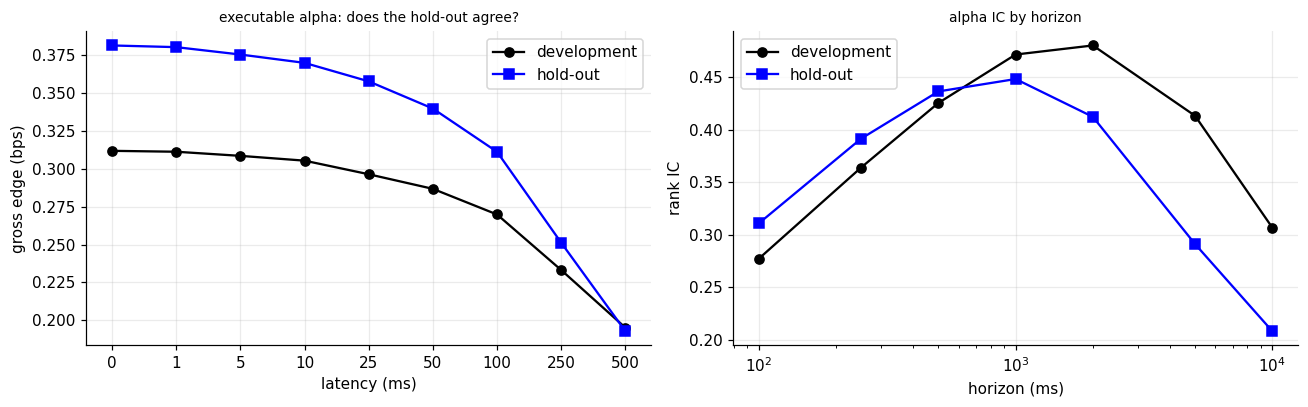


LOOK-AHEAD / INTEGRITY AUDIT SUMMARY
  PASS  1 · features(t) are bit-identical when all data after t is deleted (40 random timestamps)
  PASS  2 · every model is fitted on strictly earlier days than the day it scores
  PASS  3 · trading thresholds come from training-sample predictions only
  PASS  4 · replay engine passes all hand-built fill / latency / queue scenarios
  PASS  5 · the alpha a strategy acts on at decision time t is computed from data ≤ t − sig_lag only

<!-- AUTO-GENERATED by the notebook on 2026-09-20 05:35 UTC. -->
**Data:** BTCUSDT (binance), 6 sessions × 180 min from 09:00 UTC; 24,344,314 quote updates, 763,354 trades; tick = 0.1 (0.023 bps). Warm-up 2 d / development 2 d / hold-out 2 d.

**RQ1 – information decay (alpha rank IC, walk-forward, out-of-sample):**

| horizon (ms) | 100 | 250 | 500 | 1000 | 2000 | 5000 | 10000 |
|---|---|---|---|---|---|---|---|
| development | 0.277 | 0.364 | 0.426 | 0.472 | 0.480 | 0.413 | 0.307 |
| hold-out | 0.311 | 0.392 | 0.437 |

In [11]:
# ─────────────────────────────  11 · FROZEN HOLD-OUT EVALUATION  +  AUDIT SUMMARY  +  AUTO-GENERATED RESULTS  ─────────────────────────────
# Nothing above was tuned on these days. Config, thresholds and cut-offs are exactly the ones used on the development days.
print(f"HOLD-OUT days: {[DAYS[d].date for d in HOLD_DAYS]}{TAG}")
HOLD_RUNS = {(s, fm): [run_mm(d, s, L0, fm) for d in HOLD_DAYS] for s in "AB" for fm in QUEUE_MODELS}
rows = []
for (s, fm), runs in HOLD_RUNS.items():
    rows.append(tidy(summarize(runs, FEE0), period="hold-out", strategy=s, queue_model=QUEUE_MODELS[fm]))
for r in QSENS.itertuples():
    rows.append(dict(period="development", strategy=r.strategy, queue_model=r.queue_model, fills=r.fills, fills_per_hour=r.fills_per_hour,
                     gross_pnl=r.gross_pnl, net_pnl=r.net_pnl, half_spread_bps=r.half_spread_bps, markout_5s_bps=r.markout_5s_bps,
                     adverse_sel_5s_bps=r.adverse_sel_5s_bps, breakeven_fee_bps=r.breakeven_fee_bps, inv_std=r.inv_std))
HOLD = pd.DataFrame(rows).sort_values(["strategy", "queue_model", "period"]).set_index(["strategy", "queue_model", "period"])
display(HOLD); HOLD.to_csv(os.path.join(RES_DIR, "holdout_vs_development.csv"))

m5 = CFG["MARKOUT_MS"][1]
BM_H = boot_markout(HOLD_RUNS[("A", BASE_QUEUE_MODEL)], HOLD_RUNS[("B", BASE_QUEUE_MODEL)], m5)
print(f"Hold-out {m5//1000}s markout (bps): A {BM_H['A'][0]:+.4f}   B {BM_H['B'][0]:+.4f}   B−A {BM_H['diff'][0]:+.4f}  95% CI [{BM_H['diff'][1]:+.4f}, {BM_H['diff'][2]:+.4f}]")
LAT_H = latency_table(HOLD_DAYS, CFG["LATENCIES_MS"], H_STAR)
cmp_lat = pd.concat({"development": LAT[["gross_edge_bps", "net_of_spread_bps"]], "hold-out": LAT_H[["gross_edge_bps", "net_of_spread_bps"]]}, axis=1)
print("Executable-alpha curve: development vs hold-out"); display(cmp_lat); cmp_lat.to_csv(os.path.join(RES_DIR, "rq2_latency_dev_vs_holdout.csv"))
ic_h = {h: np.corrcoef(stats.rankdata(np.concatenate([ALPHA[(d, h)] for d in HOLD_DAYS])),
                       stats.rankdata(np.concatenate([YFWD[d][:, HI[h]] for d in HOLD_DAYS])))[0, 1] for h in H}
IC_H = pd.DataFrame({"development": IC_PIV.loc["ALPHA (walk-forward ridge)"], "hold-out": pd.Series(ic_h)}); print("Alpha IC by horizon:"); display(IC_H.T)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].plot(range(len(LAT)), LAT.gross_edge_bps, "k-o", label="development"); ax[0].plot(range(len(LAT_H)), LAT_H.gross_edge_bps, "b-s", label="hold-out")
ax[0].set_xticks(range(len(LAT))); ax[0].set_xticklabels(LAT.index); ax[0].set_xlabel("latency (ms)"); ax[0].set_ylabel("gross edge (bps)"); ax[0].legend()
ax[0].set_title("executable alpha: does the hold-out agree?" + TAG, fontsize=9)
ax[1].plot(H, IC_H["development"].values, "k-o", label="development"); ax[1].plot(H, IC_H["hold-out"].values, "b-s", label="hold-out"); ax[1].set_xscale("log")
ax[1].set_xlabel("horizon (ms)"); ax[1].set_ylabel("rank IC"); ax[1].legend(); ax[1].set_title("alpha IC by horizon", fontsize=9)
plt.tight_layout(); savefig("10_holdout"); plt.show()

print("\nLOOK-AHEAD / INTEGRITY AUDIT SUMMARY")
for k, v in AUDIT.items():
    print(("  PASS  " if v else "  FAIL  ") + k)
assert all(AUDIT.values())

# ───────────── auto-generated numbers for the README (never hand-typed) ─────────────
def g(tbl, L, col="gross_edge_bps"):
    return tbl.loc[L, col] if L in tbl.index else np.nan
def snippet():
    A1, B1 = HOLD.loc[("A", "proportional", "development")], HOLD.loc[("B", "proportional", "development")]
    Lx = [x for x in (0, 10, 50, 100, 500) if x in LAT.index]
    lines = [f"<!-- AUTO-GENERATED by the notebook on {pd.Timestamp.now(tz='UTC'):%Y-%m-%d %H:%M} UTC. " + ("SYNTHETIC DATA – DO NOT PUBLISH. -->" if SYNTH else "-->"),
             f"**Data:** {CFG['SYMBOL']} ({CFG['DATA_MODE']}), {len(DAYS)} sessions × {CFG['SESSION_MINUTES']} min from {CFG['SESSION_START_UTC']} UTC; "
             f"{sum(len(d.q_t) for d in DAYS):,} quote updates, {sum(len(d.tr_t) for d in DAYS):,} trades; tick = {DAYS[0].tick} "
             f"({DAYS[0].tick / CACHE[0]['mid'].mean() * 1e4:.3f} bps). Warm-up {len(WARM_DAYS)} d / development {len(DEV_DAYS)} d / hold-out {len(HOLD_DAYS)} d.", "",
             "**RQ1 – information decay (alpha rank IC, walk-forward, out-of-sample):**", "",
             "| horizon (ms) | " + " | ".join(str(h) for h in H) + " |", "|---|" + "---|" * len(H),
             "| development | " + " | ".join(f"{IC_H['development'][h]:.3f}" for h in H) + " |",
             "| hold-out | " + " | ".join(f"{IC_H['hold-out'][h]:.3f}" for h in H) + " |", "",
             f"**RQ2 – latency vs executable alpha ({H_STAR} ms signal, top {100*(1-CFG['TRADE_QUANTILE']):.0f}% |alpha|, held {H_STAR} ms; bps per trade):**", "",
             "| latency (ms) | " + " | ".join(str(x) for x in Lx) + " |", "|---|" + "---|" * len(Lx),
             "| gross edge – development | " + " | ".join(f"{g(LAT, x):.4f}" for x in Lx) + " |",
             "| gross edge – hold-out | " + " | ".join(f"{g(LAT_H, x):.4f}" for x in Lx) + " |",
             "| net of spread – development | " + " | ".join(f"{g(LAT, x, 'net_of_spread_bps'):.4f}" for x in Lx) + " |", "",
             f"Half-life (development): {'> ' + str(max(CFG['LATENCIES_MS'])) + ' ms' if not np.isfinite(HL) else f'{HL:.0f} ms'}. Mean half-spread cost per crossing ≈ {LAT.spread_cost_bps.iloc[0]:.4f} bps.", "",
             f"**RQ3 – queue assumption (latency {L0} ms, maker fee {FEE0} bps, development days):**", "",
             "| strategy | conservative fills / gross P&L (USDT) | proportional | optimistic |", "|---|---|---|---|"]
    for s in "AB":
        q = QSENS[QSENS.strategy == s].set_index("queue_model")
        lines.append(f"| {s} | " + " | ".join(f"{int(q.loc[m, 'fills']):,} / {q.loc[m, 'gross_pnl']:+.1f}" for m in qn) + " |")
    lines += ["", f"**RQ4/RQ5 – adverse selection, A vs B (proportional queue, latency {L0} ms, development days):**", "",
              "| metric | A naive | B order-flow-aware |", "|---|---|---|"]
    for k, nm in (("fills_per_hour", "fills / hour"), ("half_spread_at_fill_bps", "half-spread at fill (bps)"), ("markout_1s_mean_bps", "1 s markout (bps)"),
                  ("markout_5s_mean_bps", "5 s markout (bps)"), ("markout_10s_mean_bps", "10 s markout (bps)"), ("adverse_selection_5s_bps", "adverse selection 5 s (bps)"),
                  ("gross_pnl_usdt", "gross P&L (USDT)"), ("inventory_std_btc", "inventory st.dev. (BTC)"), ("quoted_time_pct", "quoted time (%)")):
        lines.append(f"| {nm} | {SUM.iloc[:, 0][k]:,.4f} | {SUM.iloc[:, 1][k]:,.4f} |")
    lines += ["", f"5 s markout difference B − A: development {BM[m5]['diff'][0]:+.4f} bps (95% CI [{BM[m5]['diff'][1]:+.4f}, {BM[m5]['diff'][2]:+.4f}]); "
                  f"hold-out {BM_H['diff'][0]:+.4f} bps (95% CI [{BM_H['diff'][1]:+.4f}, {BM_H['diff'][2]:+.4f}]).", "",
              "**RQ6 – break-even maker fee (bps; positive = a fee can be paid, negative = a rebate is needed), development days:**", "",
              "| strategy · queue | " + " | ".join(f"{L} ms" for L in CFG["LATENCIES_MS"]) + " |", "|---|" + "---|" * len(CFG["LATENCIES_MS"])]
    for s in "AB":
        for m in qn:
            lines.append(f"| {s} · {m} | " + " | ".join(f"{BE[s].loc[m, L]:+.3f}" for L in CFG["LATENCIES_MS"]) + " |")
    return "\n".join(lines)

SNIP = snippet(); print("\n" + SNIP)
with open(os.path.join(RES_DIR, "README_results_snippet.md"), "w") as f:
    f.write(SNIP)
with open(os.path.join(RES_DIR, "run_metadata.json"), "w") as f:
    json.dump(dict(config={k: v for k, v in CFG.items()}, synthetic=bool(SYNTH), tick=DAYS[0].tick, audit={k: bool(v) for k, v in AUDIT.items()},
                   numpy=np.__version__, pandas=pd.__version__, numba=numba.__version__), f, indent=2, default=str)
print(f"\nSaved figures → {FIG_DIR}\nSaved tables  → {RES_DIR}")
if IN_COLAB:
    print("Download everything:  !zip -r /content/l2e_outputs.zip /content/latency_to_execution/figures /content/latency_to_execution/results")

### What Section 11 does
Runs the **frozen** configuration on the hold-out days and puts development and hold-out side by side. Agreement is the evidence; a large gap means the development results were partly noise or over-fitted design choices, and you should say so rather than quietly re-tune (re-tuning on the hold-out would burn it).

The last cell prints the audit summary and writes `results/README_results_snippet.md` — every number in it is generated from the run, so the README never contains a hand-typed result. Do **not** publish results produced with `DATA_MODE="synthetic"`; the snippet is stamped accordingly.

**Turning results into a CV line.** Use only measured numbers, with the caveat attached, e.g. *"Built an event-driven order-book replay with a queue-aware fill model on N days of BTCUSDT L1 data; the measured gross edge of a 1 s order-flow signal fell from X to Y bps at Z ms tick-to-trade latency, and an order-flow-aware quoting rule changed 5 s markouts by W bps (95 % CI [a, b]) versus a naive maker under conservative fill assumptions."*

## Limitations and next steps
* **Venue proxy.** BTCUSDT perpetual is a research proxy for microstructure and execution mechanics. Conclusions are not assumed to transfer to NSE; tick size, fees, latency, participants and market rules differ. `DATA_MODE="custom"` lets you rerun the study on Nifty futures data you legitimately hold.
* **Level-1 data.** No depth behind the touch: multi-level OFI and true queue-position tracking need your own recorded depth stream (order-book diffs). That is the highest-value extension.
* **Fill model is a model.** Public data cannot validate queue position. The honest way to close this is to calibrate against a handful of *real* small orders and compare simulated vs actual fills.
* **Latency is fixed** here; real latency is a distribution with a tail.
* **Single instrument, few days.** Add more symbols (especially wider-tick ones, where a maker can actually improve the price) and more days before making any strong claim.
* **Ideas:** Avellaneda–Stoikov inventory skew for B; queue-reactive or Hawkes order-flow models; latency distributions; multi-level OFI; a proper cost model for NSE futures.

*References:* Cont, Kukanov & Stoikov (2014), "The Price Impact of Order Book Events"; Stoikov (2018), "The micro-price"; Avellaneda & Stoikov (2008), "High-frequency trading in a limit order book"; Huang, Lehalle & Rosenbaum (2015), "Simulating and analyzing order book data: the queue-reactive model".